# Weather Dataset — Exploratory Data Analysis & Feature Engineering
### Pipeline for Air Alarm Prediction Model

**Dataset:** Hourly weather data for cities across Ukraine (24.02.22–01.03.25)
**Goal:** EDA + preparation of the dataset for merging with alarms, ISW reports, Telegram, and Reddit


**Pipeline Structure:**
1. Loading and initial inspection
2. EDA on raw data (anomalies, distributions, relationships)
3. Preprocessing (datetime, column selection, cleaning)
4. Missing value handling
5. Duplicate removal
6. Anomaly correction
7. Feature engineering
8. Data type optimization and saving
9. Visual analysis (general + alarm-relevant)
10. Preparation of the feature matrix for the model
11. Standardization of city names for merging

## 0. Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

# ── Colab
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DATA_PATH = '/content/drive/MyDrive/data/war events/all_weather_by_hour_2023-2025_v1.csv'
    IN_COLAB = True
except ImportError:
    DATA_PATH = 'all_weather_by_hour_2023-2025_v1.csv'
    IN_COLAB = False

print(f'Running in Colab: {IN_COLAB}')

Running in Colab: False


## 1. Loading and Initial Inspection

The raw dataset contains **608,304 rows and 65 columns**. Columns follow a three-level
naming convention: `city_*` for geographic metadata, `day_*` for daily aggregates, and
`hour_*` for hourly readings — each hourly record carries a full copy of the parent day's
summary, meaning daily columns repeat across all 24 rows of each city-day group.

`.info()` confirms 47 `float64`, 4 `int64`, and 18 `object` columns. Most are fully
populated, with notable exceptions: `hour_preciptype` (64,865 non-null), `hour_visibility`
(331,846), `day_preciptype` (342,087), and `hour_solarenergy` (521,042) — all flagged as
structurally incomplete before any EDA begins.

The `.describe()` table immediately surfaces several points of interest:

- `day_tempmax` reaches **+60.4°C** and `day_tempmin` drops to **−50.3°C** — both
  physically impossible for Ukraine and visible as the darkest cells in the `max`/`min`
  columns. These are the anomalies addressed in Step 6.
- `day_precipprob` has a std of **49.9** with a median of 100 — near-bimodal, either
  fully certain or near-zero, rarely in between.
- `day_precip` mean is 2.1mm but max hits **306mm** — extreme right skew typical of
  precipitation data where most hours are dry.
- `day_pressure` is the most stable feature — std of just 8.4 hPa around a mean of
  1016.9, making it a reliable signal for gradual trend and sharp-drop features.
- `city_tzoffset` std is exactly 0 — a constant column with no informational value,
  dropped during preprocessing.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f'Shape: {raw.shape}')
print('\nColumns:', raw.columns.tolist())
raw.head(3)

Shape: (608304, 65)

Columns: ['city_latitude', 'city_longitude', 'city_resolvedAddress', 'city_address', 'city_timezone', 'city_tzoffset', 'day_datetime', 'day_datetimeEpoch', 'day_tempmax', 'day_tempmin', 'day_temp', 'day_feelslikemax', 'day_feelslikemin', 'day_feelslike', 'day_dew', 'day_humidity', 'day_precip', 'day_precipprob', 'day_precipcover', 'day_snow', 'day_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir', 'day_pressure', 'day_cloudcover', 'day_visibility', 'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'day_sunrise', 'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch', 'day_moonphase', 'day_conditions', 'day_description', 'day_icon', 'day_source', 'day_preciptype', 'day_stations', 'hour_datetime', 'hour_datetimeEpoch', 'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_snow', 'hour_snowdepth', 'hour_preciptype', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'hour_pressure', 'hour_visibility', 'hour_clo

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999


In [3]:
raw.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         608304 non-null  float64
 1   city_longitude        608304 non-null  float64
 2   city_resolvedAddress  608304 non-null  object 
 3   city_address          608304 non-null  object 
 4   city_timezone         608304 non-null  object 
 5   city_tzoffset         608304 non-null  float64
 6   day_datetime          608304 non-null  object 
 7   day_datetimeEpoch     608304 non-null  int64  
 8   day_tempmax           608304 non-null  float64
 9   day_tempmin           608304 non-null  float64
 10  day_temp              608304 non-null  float64
 11  day_feelslikemax      608304 non-null  float64
 12  day_feelslikemin      608304 non-null  float64
 13  day_feelslike         608304 non-null  float64
 14  day_dew               608304 non-null  float64
 15  

In [4]:
raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','min','max'], axis = 1)

,count,mean,std,min,25%,50%,75%,max
city_latitude,608304.000000,49.143238,1.337209,46.472500,48.292400,49.416800,50.253600,51.493700
city_longitude,608304.000000,30.142514,4.303973,22.285100,25.935500,30.737100,34.551700,37.814500
city_tzoffset,608304.000000,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
day_datetimeEpoch,608304.000000,1693216799.591651,27485575.882872,1645653600.000000,1669413600.000000,1693256400.000000,1717016400.000000,1740780000.000000
day_tempmax,608304.000000,15.203232,10.592473,-14.300000,5.900000,15.100000,24.600000,60.400000
day_tempmin,608304.000000,6.253993,8.162055,-50.300000,-0.200000,6.100000,13.200000,27.200000
day_temp,608304.000000,10.721077,9.207622,-17.500000,2.800000,10.600000,18.800000,33.200000
day_feelslikemax,608304.000000,14.287248,11.577354,-21.800000,3.800000,15.100000,24.600000,60.400000
day_feelslikemin,608304.000000,4.267318,9.929590,-50.300000,-3.800000,4.200000,13.200000,28.000000
day_feelslike,608304.000000,9.254504,10.713666,-27.100000,-0.100000,9.900000,18.800000,33.900000


### 1.1 Overview of Unique Values in Key Columns

At this stage, we examine the unique values in several key columns to better understand the structure of the raw weather dataset before preprocessing. This overview helps identify the geographic coverage of the data, the time span it covers, and the cardinality of important categorical variables.

The dataset includes **23 Ukrainian cities** and spans from **2022-02-24 to 2025-03-01**, providing broad regional and temporal coverage for further analysis. Among the weather-related categorical columns, **`day_icon`** contains **7 unique values**, **`day_conditions`** has **19**, and **`hour_conditions`** has **16**, which shows that the dataset captures a manageable variety of weather states at both daily and hourly levels.

The **`day_moonphase`** column ranges from **0.00 to 1.00** with **101 unique values**, meaning it is stored as a normalized numerical feature.

This step gives a clearer picture of the dataset composition and helps distinguish compact categorical variables from high-cardinality or continuous features before moving to deeper exploratory analysis and preprocessing.

In [5]:
# Unique cities
print('Cities:', sorted(raw['city_address'].unique().tolist()))
print('\nTime range:')
print(' min:', raw['day_datetime'].min(), '| max:', raw['day_datetime'].max())

Cities: ['Cherkasy,Ukraine', 'Chernihiv,Ukraine', 'Chernivtsi,Ukraine', 'Dnipro,Ukraine', 'Donetsk,Ukraine', 'Ivano-Frankivsk,Ukraine', 'Kharkiv,Ukraine', 'Kherson,Ukraine', 'Khmelnytskyi,Ukraine', 'Kropyvnytskyi,Ukraine', 'Kyiv,Ukraine', 'Lutsk,Ukraine', 'Lviv,Ukraine', 'Mykolaiv,Ukraine', 'Odesa,Ukraine', 'Poltava,Ukraine', 'Rivne,Ukraine', 'Sumy,Ukraine', 'Ternopil,Ukraine', 'Uzhgorod,Ukraine', 'Vinnytsia,Ukraine', 'Zaporozhye,Ukraine', 'Zhytomyr,Ukraine']

Time range:
 min: 2022-02-24 | max: 2025-03-01


In [6]:
# Useful caterogical columns
for col in ['day_icon', 'day_conditions', 'hour_conditions']:
    print(f'{col}: {raw[col].nunique()} unique → {raw[col].unique().tolist()}\n')

day_icon: 7 unique → ['snow', 'rain', 'partly-cloudy-day', 'clear-day', 'cloudy', 'fog', 'wind']

day_conditions: 19 unique → ['Snow, Partially cloudy', 'Rain, Partially cloudy', 'Partially cloudy', 'Snow, Rain, Partially cloudy', 'Overcast', 'Snow, Overcast', 'Snow, Rain, Overcast', 'Clear', 'Rain, Overcast', 'Snow, Rain, Freezing Drizzle/Freezing Rain, Overcast', 'Rain', 'Snow, Freezing Drizzle/Freezing Rain, Overcast', 'Snow, Rain, Freezing Drizzle/Freezing Rain, Partially cloudy', 'Rain, Freezing Drizzle/Freezing Rain, Overcast', 'Snow, Freezing Drizzle/Freezing Rain, Partially cloudy', 'Snow, Rain', 'Snow, Freezing Drizzle/Freezing Rain, Ice, Overcast', 'Snow, Rain, Ice, Overcast', 'Snow']

hour_conditions: 16 unique → ['Overcast', 'Partially cloudy', 'Snow, Overcast', 'Clear', 'Rain, Overcast', 'Rain, Partially cloudy', 'Snow, Rain, Partially cloudy', 'Snow, Partially cloudy', 'Snow, Rain, Overcast', 'Rain', 'Freezing Drizzle/Freezing Rain, Overcast', 'Snow', 'Snow, Rain', 'Ice, 

Only in day_conditions:
{'Rain, Freezing Drizzle/Freezing Rain, Overcast', 'Snow, Freezing Drizzle/Freezing Rain, Ice, Overcast', 'Snow, Rain, Freezing Drizzle/Freezing Rain, Overcast', 'Snow, Freezing Drizzle/Freezing Rain, Overcast', 'Snow, Freezing Drizzle/Freezing Rain, Partially cloudy', 'Snow, Rain, Freezing Drizzle/Freezing Rain, Partially cloudy', 'Snow, Rain, Ice, Overcast'}

Only in hour_conditions:
{'Freezing Drizzle/Freezing Rain, Overcast', 'Ice, Overcast', 'Snow, Rain, Fog', 'Rain, Fog'}

Shared values:
{'Snow, Partially cloudy', 'Clear', 'Snow, Rain, Overcast', 'Overcast', 'Snow', 'Rain, Overcast', 'Snow, Overcast', 'Rain, Partially cloudy', 'Snow, Rain, Partially cloudy', 'Snow, Rain', 'Rain', 'Partially cloudy'}


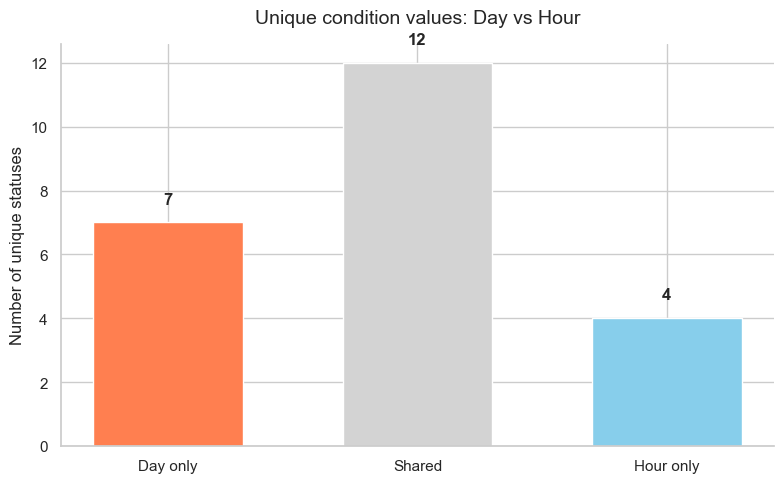

In [7]:
# 1. Get unique values, drop NaN
day_cond  = set(raw['day_conditions'].dropna().unique())
hour_cond = set(raw['hour_conditions'].dropna().unique())

# 2. Find differences and overlap
only_day  = day_cond - hour_cond
only_hour = hour_cond - day_cond
common    = day_cond.intersection(hour_cond)

# 3. Print values to inspect differences
print("Only in day_conditions:")
print(only_day if only_day else "None")

print("\nOnly in hour_conditions:")
print(only_hour if only_hour else "None")

print("\nShared values:")
print(common)

# 4. Bar chart
categories = ['Day only', 'Shared', 'Hour only']
counts     = [len(only_day), len(common), len(only_hour)]

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts, color=['coral', 'lightgray', 'skyblue'], width=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             int(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Unique condition values: Day vs Hour', fontsize=14, pad=15)
plt.ylabel('Number of unique statuses')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
# Moonphase values
print('Moon phases:', sorted(raw['day_moonphase'].unique()))

Moon phases: [np.float64(0.0), np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.08), np.float64(0.09), np.float64(0.1), np.float64(0.11), np.float64(0.12), np.float64(0.13), np.float64(0.14), np.float64(0.15), np.float64(0.16), np.float64(0.17), np.float64(0.18), np.float64(0.19), np.float64(0.2), np.float64(0.21), np.float64(0.22), np.float64(0.23), np.float64(0.24), np.float64(0.25), np.float64(0.26), np.float64(0.27), np.float64(0.28), np.float64(0.29), np.float64(0.3), np.float64(0.31), np.float64(0.32), np.float64(0.33), np.float64(0.34), np.float64(0.35), np.float64(0.36), np.float64(0.37), np.float64(0.38), np.float64(0.39), np.float64(0.4), np.float64(0.41), np.float64(0.42), np.float64(0.43), np.float64(0.44), np.float64(0.45), np.float64(0.46), np.float64(0.47), np.float64(0.48), np.float64(0.49), np.float64(0.5), np.float64(0.51), np.float64(0.52), np.float64(0.53), np.float64(0.54), np

## 2. Exploratory Data Analysis on Raw Weather Data


> **Principle:** EDA is performed on the raw, unmodified dataset — to detect anomalies
> and understand the structure of the data *before* any cleaning or transformation is applied.

All five subsections in this chapter operate directly on `raw`, the original DataFrame loaded
from CSV. This ordering is intentional: cleaning decisions should be informed by what the data
actually contains, not by assumptions made in advance.

The analysis covers five dimensions, each targeting a specific type of data quality issue:


- **2.1 Temporal coverage and record distribution** — to check how the observations are distributed over time, whether the dataset covers the full study period consistently, and whether there are any visible gaps or irregular drops in the number of records.

- **2.2 City-level distribution of records** — to compare the number of observations across cities and verify that the dataset has broad regional coverage. This also helps detect whether some cities are overrepresented or underrepresented.

- **2.3 Distributions of main numerical weather features** — to inspect the value ranges, central tendencies, spread, and skewness of variables such as temperature, humidity, pressure, wind speed, cloud cover, and precipitation. This step helps reveal unusual values and variables that may need transformation.

- **2.4 Outlier inspection and anomaly detection** — to identify extreme or potentially unrealistic values in the raw data. Since weather variables may contain rare but valid extremes, this step is used to separate suspicious observations from naturally unusual weather conditions.

- **2.5 Relationships between key weather variables** — to examine how atmospheric features interact with each other and whether some variables move together. This is useful for understanding redundancy, dependency structure, and possible predictors for downstream modeling.


### 2.1.1 Missing Values Across All Columns

The chart immediately splits columns into three tiers by severity. `hour_preciptype` stands
alone at ~89% missing — nearly 9 in 10 rows have no value, making it effectively unusable
as a feature. `hour_visibility` and `day_preciptype` sit in the 43–45% range, meaning fewer
than half of all rows carry a valid reading for either column. These three are the clear
drop candidates.

`hour_solarenergy` is missing in ~14% of rows, and `day_visibility` in ~9% — both significant
enough to require imputation but not disqualifying on their own. `hour_solarradiation` and
`hour_uvindex` are near the zero line (~0.7%), meaning data is almost complete. Daily solar
and UV columns are effectively clean at under 0.1%.

Only `hour_precip` has a near-invisible bar (0.017%, ~102 rows) — a trivial gap easily
filled by rolling imputation. The overall picture confirms that missingness is concentrated
in a small set of columns, and the majority of the dataset is structurally complete.

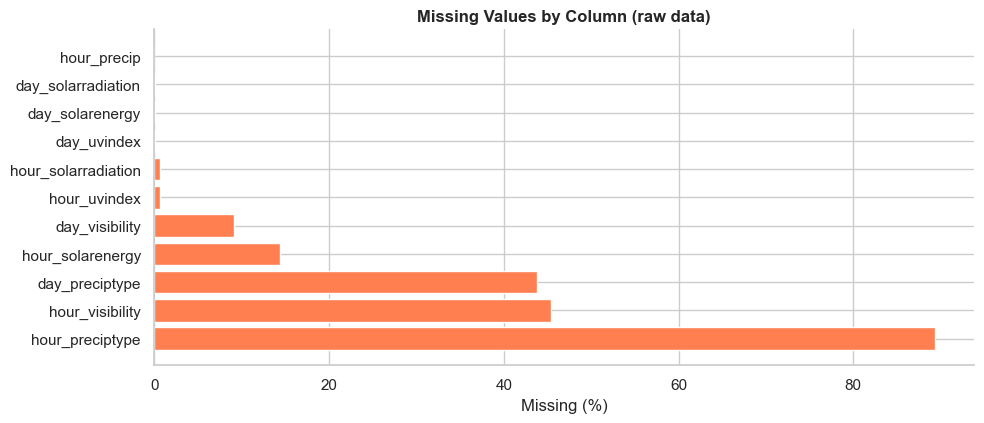

             column  missing_%
    hour_preciptype  89.336746
    hour_visibility  45.447342
     day_preciptype  43.763809
   hour_solarenergy  14.345130
     day_visibility   9.099398
       hour_uvindex   0.712801
hour_solarradiation   0.712801
        day_uvindex   0.090744
    day_solarenergy   0.090744
 day_solarradiation   0.090744
        hour_precip   0.016768


In [9]:
missing = (raw.isna().sum() / len(raw) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['column', 'missing_%']

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.4)))
    ax.barh(missing_df['column'], missing_df['missing_%'], color='coral')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column (raw data)', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()
    print(missing_df.to_string(index=False))
else:
    print('No missing values in raw data.')

### 2.1.2 Visibility Data — Missingness Structure

The intersection matrix reveals a clean, one-sided missingness pattern: every row where
`hour_visibility` is present also has a valid `day_visibility` value (0 exceptions).
The reverse is not true — **221,106 rows** have `day_visibility` available while
`hour_visibility` is missing, making them direct fill candidates. The remaining **55,352**
rows have both columns absent and cannot be recovered from within the dataset.

The year-by-year breakdown exposes a structural shift in data collection: 2022 is the
only year with consistent hourly visibility coverage (~311 days with both values present).
From 2023 onward, hourly readings become sparse — nearly all days fall into the
"partial hour / day present" category, meaning `day_visibility` is the only reliable
visibility signal for the majority of the dataset's time span.

**Conclusion:** filling missing `hour_visibility` values with the corresponding
`day_visibility` is both feasible and well-grounded — the day-level value is always
available when the hour-level one is missing, and it represents the best available
proxy given the collection gap that begins in 2023.

Later, in the next section **`4.2 Visibility Imputation`** we will rectify this problem.

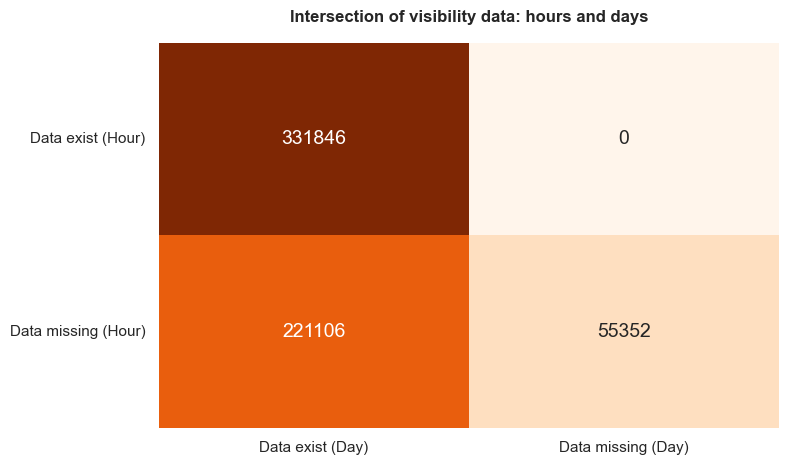

In [10]:
# count intersection
overlap = pd.crosstab(
    raw['hour_visibility'].isna(), 
    raw['day_visibility'].isna(), 
    rownames=['hour_visibility'], 
    colnames=['day_visibility']
)

# naming
overlap.index = ['Data exist (Hour)', 'Data missing (Hour)']
overlap.columns = ['Data exist (Day)', 'Data missing (Day)']

# intersection plot
plt.figure(figsize=(8, 5))
sns.heatmap(overlap, annot=True, fmt='d', cmap='Oranges', cbar=False, annot_kws={"size": 14})
plt.title('Intersection of visibility data: hours and days', fontweight='bold', pad=15)
plt.yticks(rotation=0)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_30896\1212781326.py:39: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


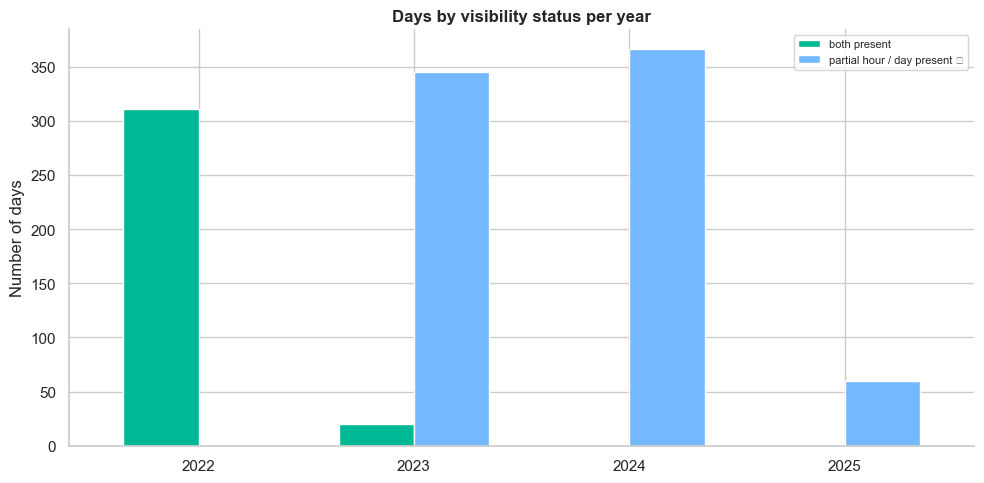

In [11]:
raw['_hour_missing'] = raw['hour_visibility'].isna()
raw['_day_missing']  = raw['day_visibility'].isna()

daily = raw.groupby('day_datetime').agg(
    hour_missing_count = ('_hour_missing', 'sum'),
    hour_total         = ('_hour_missing', 'count'),
    day_missing        = ('_day_missing',  'first'),
).reset_index()

daily['hour_missing_pct'] = daily['hour_missing_count'] / daily['hour_total'] * 100
daily['status'] = 'both present'
daily.loc[daily['day_missing'] & (daily['hour_missing_pct'] == 100),  'status'] = 'both missing'
daily.loc[daily['day_missing'] & (daily['hour_missing_pct'] < 100),   'status'] = 'day missing / hour partial'
daily.loc[~daily['day_missing'] & (daily['hour_missing_pct'] == 100), 'status'] = 'hour missing / day present ✓'
daily.loc[~daily['day_missing'] & (daily['hour_missing_pct'] > 0) &
          (daily['hour_missing_pct'] < 100),                           'status'] = 'partial hour / day present ✓'

status_colors = {
    'both present':                '#00b894',
    'both missing':                '#d63031',
    'hour missing / day present ✓':'#fdcb6e',
    'partial hour / day present ✓':'#74b9ff',
    'day missing / hour partial':  '#a29bfe',
}

daily['_year'] = pd.to_datetime(daily['day_datetime']).dt.year
yearly = daily.groupby(['_year','status']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
yearly.plot(kind='bar', ax=ax,
            color=[status_colors.get(c, 'gray') for c in yearly.columns],
            edgecolor='white', width=0.7)
ax.set_title('Days by visibility status per year', fontweight='bold')
ax.set_ylabel('Number of days')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Cleanup
raw.drop(columns=['_hour_missing', '_day_missing'], inplace=True)

### 2.2 Detecting Anomalies - Temperature Distribution in Raw Data

The histogram on the left shows a bimodal distribution — a clear cold peak near 0°C and a
broader warm peak around 15–20°C, which is exactly what is expected for Ukrainian climate
across a three-year period spanning all seasons. The bulk of readings falls well within the
[−35, +45]°C thresholds marked by the dashed lines, confirming the distribution is realistic.

The right panel — boxplots per city — reveals a highly consistent picture across all 23
locations. Medians (red lines) cluster between roughly 8–12°C, and IQR ranges are nearly
identical city to city, as expected for cities within the same country and climate zone.
Whiskers extend down to approximately −20°C in most cities, which is physically plausible
for Ukrainian winters.

One outlier breaks this pattern entirely: `Zaporizhzhia` shows a single point at +60.4°C,
sitting far above the red dotted threshold line — visually isolated from every other
observation in the dataset. The `Khmelnytskyi` boxplot also shows a low outlier near −50°C,
which corresponds to the same city's second erroneous reading. Both are unambiguous sensor
failures and are treated as such in **Step 6**.

C:\Users\DELL\AppData\Local\Temp\ipykernel_30896\1974767237.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(temp_by_city,


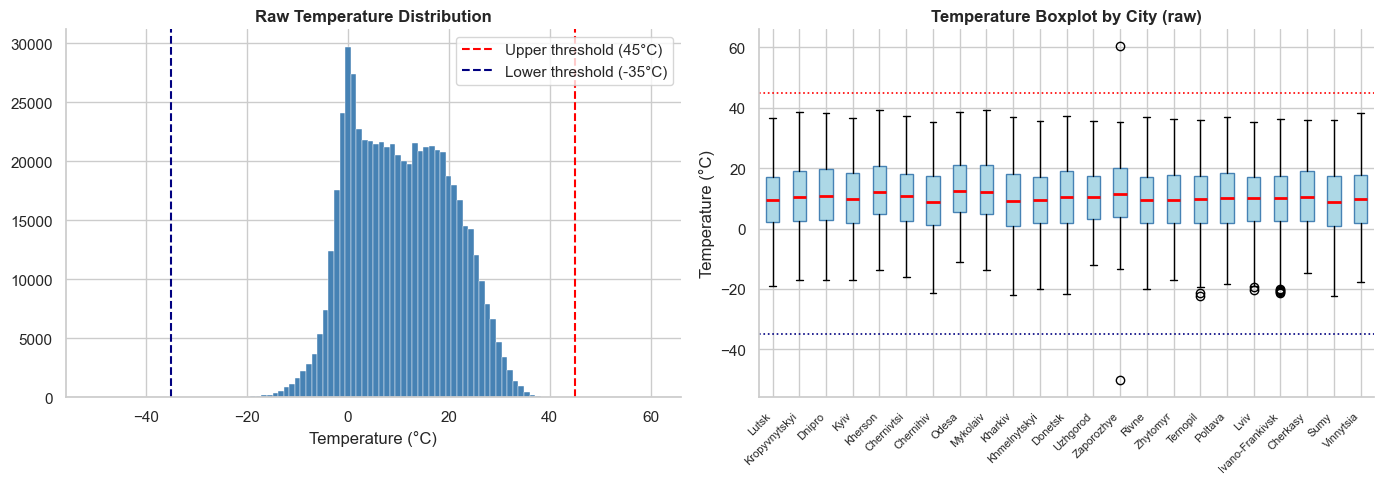

Suspicious temperature rows: 2
              city_address day_datetime hour_datetime  hour_temp
106388  Zaporozhye,Ukraine   2022-07-03      21:00:00       60.4
108860  Zaporozhye,Ukraine   2022-10-14      21:00:00      -50.3


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гістограма
ax = axes[0]
ax.hist(raw['hour_temp'].dropna(), bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(45,  color='red',    linestyle='--', linewidth=1.5, label='Upper threshold (45°C)')
ax.axvline(-35, color='navy',   linestyle='--', linewidth=1.5, label='Lower threshold (-35°C)')
ax.set_title('Raw Temperature Distribution', fontweight='bold')
ax.set_xlabel('Temperature (°C)')
ax.legend()
ax.spines[['top','right']].set_visible(False)

# Boxplot по містах
ax = axes[1]
city_labels = raw['city_address'].str.replace(',Ukraine','',regex=False)
temp_by_city = [raw.loc[raw['city_address']==c, 'hour_temp'].dropna().values
                for c in raw['city_address'].unique()]
ax.boxplot(temp_by_city,
           labels=[c.replace(',Ukraine','') for c in raw['city_address'].unique()],
           vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.axhline(45, color='red', linestyle=':', linewidth=1.2)
ax.axhline(-35, color='navy', linestyle=':', linewidth=1.2)
ax.set_title('Temperature Boxplot by City (raw)', fontweight='bold')
ax.set_ylabel('Temperature (°C)')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

suspicious = raw[(raw['hour_temp'] > 45) | (raw['hour_temp'] < -35)]
print(f'Suspicious temperature rows: {len(suspicious)}')
if len(suspicious) > 0:
    print(suspicious[['city_address','day_datetime','hour_datetime','hour_temp']].to_string())

### 2.3 Z-score Analysis — Systematic Outlier Detection

We performed a systematic `Z-score analysis`, a statistical method used to measure how
far each value is from the mean in units of standard deviation. This helps detect
unusually extreme observations that may indicate potential outliers.

The printed table ranks all numerical columns by the share of rows with |z| > 4.
The overall picture is reassuring — the dataset is remarkably clean. For most core
meteorological variables the outlier rate is either a negligible fraction of a percent
or entirely absent, as is the case for hourly temperature readings.

Precipitation and snow columns dominate the top — `day_snowdepth` (1.59%),
`day_precipcover` (1.46%), `day_snow` (1.21%), `hour_snow` (1.05%), `hour_snowdepth`
(0.97%). Statistically the algorithm flags these as outliers, but physically they almost
certainly represent genuine heavy snowfall or rainfall events. Since the vast majority of
days in Ukraine record zero snow, any significant snowfall pulls sharply away from the
distribution mean. These rows should not be removed blindly — they describe real, rare
weather phenomena with potential predictive value.

Wind and visibility columns follow at 0.1–0.25% — a moderate outlier rate that could
reflect either genuine storm events and dense fog, or isolated sensor failures. Without
additional context these rows are retained.

Temperature anomalies account for just 0.004% of rows — confirming that the physically
impossible readings identified in section 2.2 (−50°C, +60°C) are truly isolated
incidents. They can be corrected without any meaningful loss of data coverage, which is
exactly the approach taken in **`Step 6`**.

The combined picture confirms there are no systemic data quality problems — outliers are
either rare natural extremes that should be kept, or the two isolated sensor failures
that are safely corrected later in the pipeline.

In [13]:
num_raw = raw.select_dtypes(include='number').columns.tolist()
zscore_outliers = {}
for col in num_raw:
    z = np.abs(stats.zscore(raw[col].dropna()))
    pct = (z > 4).mean() * 100
    if pct > 0:
        zscore_outliers[col] = round(pct, 3)

outlier_df = pd.DataFrame.from_dict(zscore_outliers, orient='index', columns=['outlier_%']).sort_values('outlier_%', ascending=False)
print('Columns with Z-score > 4 outliers (% of rows):')
print(outlier_df)

C:\Users\DELL\AppData\Local\Temp\ipykernel_30896\3072154343.py:4: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z = np.abs(stats.zscore(raw[col].dropna()))


Columns with Z-score > 4 outliers (% of rows):
                  outlier_%
day_snowdepth         1.594
day_precipcover       1.460
day_snow              1.207
hour_snow             1.048
hour_snowdepth        0.970
day_precip            0.323
day_windspeed         0.253
day_visibility        0.235
day_windgust          0.181
hour_precip           0.160
hour_windgust         0.114
hour_windspeed        0.113
hour_visibility       0.034
hour_pressure         0.020
day_pressure          0.008
day_tempmax           0.004
day_feelslikemin      0.004
day_tempmin           0.004
hour_temp             0.000
hour_feelslike        0.000
hour_dew              0.000


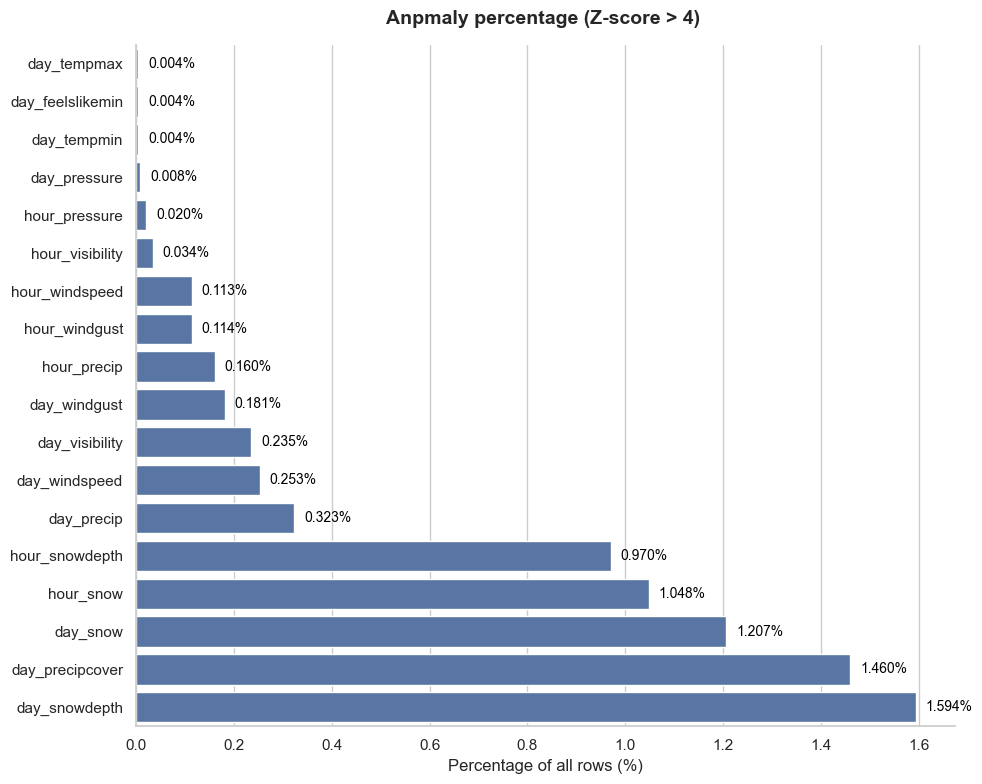

In [14]:
plot_df = outlier_df[outlier_df['outlier_%'] > 0].copy().sort_values(by='outlier_%', ascending=True).copy()

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=plot_df, 
    x='outlier_%', 
    y=plot_df.index, 
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.02, p.get_y() + p.get_height() / 2, 
            f'{width:.3f}%', 
            ha='left', va='center', fontsize=10, color='black')

plt.title('Anpmaly percentage (Z-score > 4) ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of all rows (%)', fontsize=12)
plt.ylabel('')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 2.4 Number of Records by City and Year — Balance Check

The heatmap is a near-perfect uniform grid — every city, every year shows an identical
count with no gaps or lighter cells anywhere. The numbers are arithmetically exact:
**7,464** records in 2022 (311 days × 24 hours, since data starts 24.02.2022),
**8,760** in 2023 (365 × 24), **8,784** in 2024 (366 × 24, leap year), and **1,440**
in 2025 (60 days × 24, data ends 01.03.2025).

This confirms that the collection pipeline was perfectly consistent — all 23 cities were
recorded continuously and simultaneously without a single missing hour across the entire
period. The dataset requires no coverage correction before modeling, and the city dimension
can be used as a reliable grouping key in all subsequent steps.

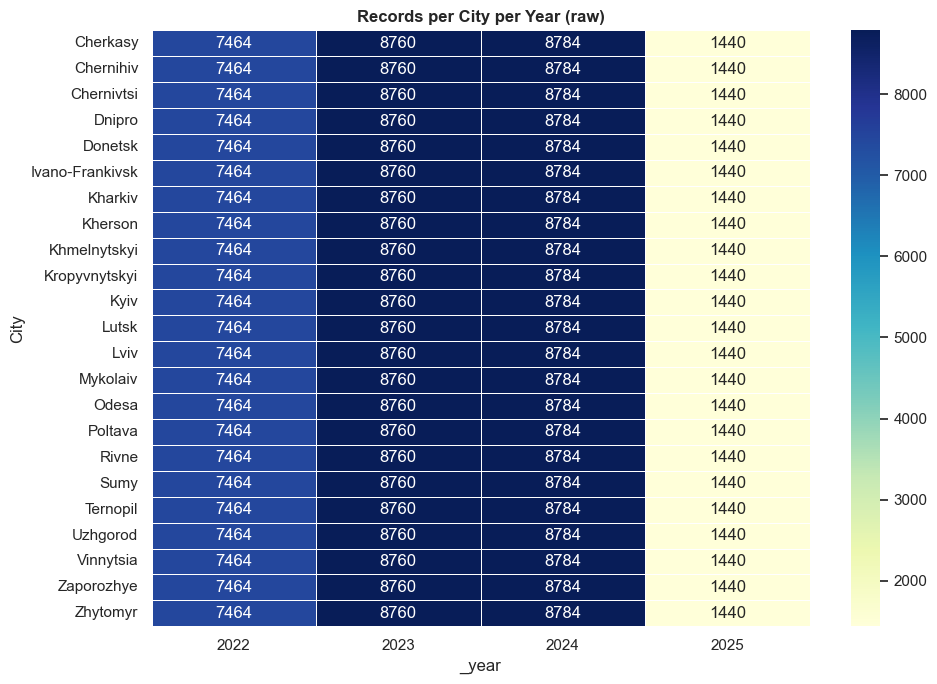

In [15]:
raw['_year'] = pd.to_datetime(raw['day_datetime'], errors='coerce').dt.year
pivot_coverage = raw.groupby(['city_address','_year']).size().unstack(fill_value=0)
pivot_coverage.index = pivot_coverage.index.str.replace(',Ukraine','',regex=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_coverage, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.4, ax=ax)
ax.set_title('Records per City per Year (raw)', fontweight='bold')
ax.set_ylabel('City')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### 2.5 Correlation Matrix on Raw Data

The correlation matrix shows how the main hourly weather variables move together in the
raw dataset. Most relationships are fairly weak, which means the features capture
different aspects of weather conditions rather than duplicating each other.

Two pairs stand out with strong correlations. **`hour_windspeed`** and **`hour_windgust`**
at **+0.84** — expected, as stronger sustained wind is always accompanied by stronger
gusts. These two variables are closely connected and may prove redundant as independent
features. **`hour_temp`** and **`hour_dew`** at **+0.86** — the strongest relationship
in the entire matrix. Dew point rises with temperature since warmer air holds more
moisture, making these two highly collinear. This is worth noting before feature
selection.

Other notable relationships: `hour_temp` ↔ `hour_humidity` (**−0.58**) — warmer hours
tend to be drier in relative terms. `hour_temp` ↔ `hour_pressure` (**−0.33**) and
`hour_temp` ↔ `hour_cloudcover` (**−0.26**) are moderate negative links consistent
with continental climate patterns. `hour_humidity` ↔ `hour_cloudcover` (**+0.35**) and
`hour_dew` ↔ `hour_pressure` (**−0.42**) — the latter being the second strongest
negative pair in the matrix, reflecting that low-pressure systems bring moist, humid air.
`hour_visibility` shows a moderate negative link with `hour_humidity` (**−0.29**),
confirming that higher humidity tends to reduce visibility.

`day_moonphase` shows near-zero correlations with every variable in the matrix —
the strongest being **−0.05** with `hour_dew`, and all others at or below **0.02** in
absolute value. This confirms that moon phase is effectively independent of all measured
atmospheric conditions, which is expected — it is an astronomical cycle with no direct
physical link to hourly weather. Its value for the model lies not in atmospheric
relationships but as a potential proxy for nighttime illumination conditions relevant
to air raid timing.

Precipitation and precipitation probability remain weakly correlated with most variables,
suggesting they capture short-term local effects not well represented by the other
features. Taken together, the matrix reveals two pairs requiring attention in feature
selection (`windspeed`/`windgust` and `temp`/`dew`), while the rest of the feature set
appears sufficiently distinct to remain useful for modeling.

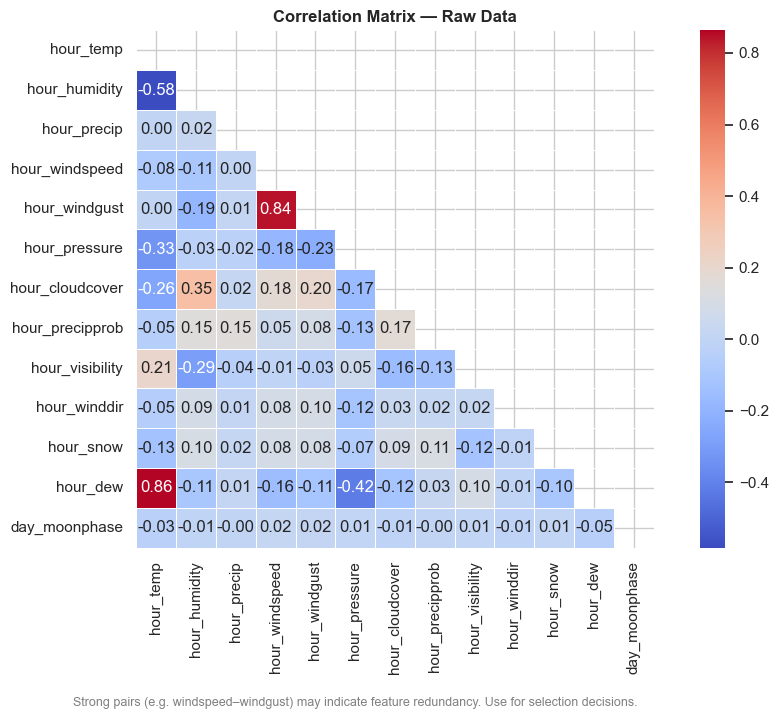

In [16]:
core_raw = ['hour_temp','hour_humidity','hour_precip','hour_windspeed',
            'hour_windgust','hour_pressure','hour_cloudcover','hour_precipprob', 'hour_visibility', 'hour_winddir', 'hour_snow', 'hour_dew', 'day_moonphase']
corr_raw = raw[core_raw].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_raw, dtype=bool))
sns.heatmap(corr_raw, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5, ax=ax, mask=mask)
ax.set_title('Correlation Matrix — Raw Data', fontweight='bold')
fig.text(0.5, -0.02,
    'Strong pairs (e.g. windspeed–windgust) may indicate feature redundancy. Use for selection decisions.',
    ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

---

## 3. Preprocessing

### 3.1 Building the Datetime Column & Column Selection

The raw dataset stores date and time in two separate columns — `day_datetime` (calendar date)
and `hour_datetime` (time within that day). These are concatenated into a single string and
parsed into a proper `datetime` object using `pd.to_datetime()` with `errors='coerce'`, which
silently converts any malformed entries to `NaT` instead of raising an exception. This produces
a clean, continuous hourly index covering the full period from 2022-02-24 through 2025-03-01.

A `region` column is derived in the same step by stripping `",Ukraine"` from `city_address`,
producing a short city-name label that will be used as a join key when merging with other
datasets — alarms, ISW reports, and Reddit.

From the original 65 columns, only 16 are retained. All selected features come from the
**hourly** granularity rather than daily aggregates — this is intentional, since
the target variable (air alarm) is also hourly. The kept columns fall into four groups:

- **Location & time** — `region`, `datetime`
- **Temperature & humidity** — `temp`, `humidity`, `dew`, `pressure`. Dew point is kept
  specifically as a fog detection signal.
- **Precipitation & cloud** — `precip`, `precipprob`, `cloudcover`, `snow`
- **Wind** — `windspeed`, `winddir`. Direction is retained in raw degree form here;
  cyclical sin/cos encoding is applied later in Feature Engineering.
- **Conditions & light** — `day_sunrise`, `day_sunset`, `conditions`, `icon`, `moonphase`.
  Moon phase is included as an optional signal for night-time attack analysis.

Two helper columns are added at the end: `date` (calendar date, time stripped via
`.dt.normalize()`) for daily groupings, and `hours` (integer 0–23) as a direct temporal
feature for the model.

After selection the dataset is reduced from 65 to **18 columns**, with all 608,304 rows intact.

In [17]:
weather = raw.copy()

weather['datetime'] = pd.to_datetime(
    weather['day_datetime'].astype(str) + ' ' + weather['hour_datetime'].astype(str),
    errors='coerce'
)

weather['region'] = weather['city_address'].str.replace(',Ukraine', '', regex=False)

keep = {
    'region':    'city',
    'datetime':        'datetime',

    'hour_temp':       'temp',
    'hour_humidity':   'humidity',
    'hour_dew':        'dew',
    'hour_pressure':   'pressure',

    'hour_precip':     'precip',
    'hour_precipprob': 'precipprob',
    'hour_cloudcover': 'cloudcover',
    'hour_snow': 'snow',

    'hour_windspeed':  'windspeed',
    'hour_winddir':    'winddir',   
    'hour_windgust':   'windgust',

    'hour_visibility': 'visibility',
    'day_visibility': 'day_visibility',
    'day_sunrise':     'day_sunrise',
    'day_sunset':      'day_sunset',
    'day_conditions': 'day_conditions',
    'hour_conditions': 'conditions',
    'hour_icon': 'icon',
    'day_moonphase':   'day_moonphase'

}

keep_filtered = {k: v for k, v in keep.items() if k in weather.columns}
weather = weather[list(keep_filtered.keys())].rename(columns=keep_filtered)

weather['date']  = weather['datetime'].dt.normalize()
weather['hours'] = weather['datetime'].dt.hour

print(f'Shape after column selection: {weather.shape}')
weather.head(3)

Shape after column selection: (608304, 23)


,city,datetime,temp,humidity,dew,pressure,precip,precipprob,cloudcover,snow,windspeed,winddir,windgust,visibility,day_visibility,day_sunrise,day_sunset,day_conditions,conditions,icon,day_moonphase,date,hours
0,Lutsk,2022-02-24 00:00:00,2.4,89.18,0.8,1020.0,0.0,0.0,91.5,0.1,15.5,275.6,31.3,0.0,12.2,07:13:36,17:51:06,"Snow, Partially cloudy",Overcast,snow,0.77,2022-02-24,0
1,Lutsk,2022-02-24 01:00:00,2.4,87.90,0.6,1021.0,0.0,0.0,88.2,0.0,14.8,280.3,27.7,0.2,12.2,07:13:36,17:51:06,"Snow, Partially cloudy",Partially cloudy,fog,0.77,2022-02-24,1
2,Lutsk,2022-02-24 02:00:00,2.9,88.58,1.2,1022.0,0.0,0.0,100.0,0.0,14.4,310.0,29.2,10.0,12.2,07:13:36,17:51:06,"Snow, Partially cloudy",Overcast,cloudy,0.77,2022-02-24,2


---

## 4. Missing value handling

### 4.1 General Imputation

Before any imputation, the dataset is sorted by `city` and `datetime` to ensure that
all time-based fill operations follow chronological order within each city. This is a
necessary precondition — applying a rolling window on unsorted data would produce
meaningless results.

The pre-imputation audit reveals only a single column with missing values: `precip` with
**102 null rows** out of 608,304. All other columns in the reduced feature set are
already complete at this stage — a direct consequence of the aggressive column selection
in Step 3, which dropped the structurally incomplete columns (`hour_preciptype`,
`hour_visibility`, `hour_solarenergy`) before imputation was even needed.

Three distinct strategies are applied, each matched to the nature of the column:

**Numerical columns — 24-hour rolling mean per region.** For each numeric column, missing
values are filled using a rolling window of 24 hours computed separately within each city
group. `min_periods=1` ensures the window produces a value even at the start of the series
where fewer than 24 prior observations exist. This approach is deliberately conservative:
instead of pulling a global or cross-city average, it uses only the recent local context
of that specific city's time series — preserving the temporal and geographical structure
of the data.

After all three strategies are applied, the output confirms: **None — clean!** — zero
missing values remain across the entire dataset. The 102 missing `precip` rows were the
only real problem, and they were resolved by the rolling mean without any row being dropped.

In [18]:
weather = weather.sort_values(['city', 'datetime']).reset_index(drop=True)

print('Missing values BEFORE imputation:')
missing_before = weather.isna().sum()
print(missing_before[missing_before > 0])

Missing values BEFORE imputation:
precip               102
visibility        276458
day_visibility     55352
dtype: int64


In [19]:
weather['precip'] = weather['precip'].ffill()

In [20]:
print('\nMissing values AFTER imputation:')
remaining = weather.isna().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None — clean!')


Missing values AFTER imputation:
visibility        276458
day_visibility     55352
dtype: int64


### 4.2 Visibility Imputation

As established in section 2.1.1, `hour_visibility` has a structural missingness pattern
that cannot be resolved by rolling imputation alone — the gaps are not random but
systematic, covering entire days from 2023 onward. Standard rolling mean would simply
propagate stale values across hundreds of consecutive missing hours, producing an
unreliable flat signal.

1. **Linear interpolation** (`limit=3`) — fills short gaps of up to 3 consecutive
   missing hours using surrounding valid readings.
2. **`day_visibility` fallback** — fills remaining longer gaps with the corresponding
   daily value, which covers `221,230` rows where the hourly reading is absent but
   the day-level value exists.
4. **Forward fill** — closes the residual `55,228` rows where both hourly and daily
   values are absent, carrying the last valid observation forward.

Result: **0 missing values remaining.**

In [21]:
weather = weather.sort_values(['city', 'datetime']).reset_index(drop=True)

# Step 1: Linear interpolation
weather['visibility'] = weather.groupby('city')['visibility'].transform(
    lambda x: x.interpolate(method='linear', limit=3)
)

# Step 2: Fill remaining longer gaps (4+ hours) with day_visibility.
weather['visibility'] = weather['visibility'].fillna(weather['day_visibility'])

remaining_missing = weather['visibility'].isna().sum()
print(f"Missing after combined fill: {remaining_missing}")

Missing after combined fill: 55228


In [22]:
weather['visibility'] = weather.groupby('city')['visibility'].transform(
    lambda x: x.ffill()
)

# Final check
final_missing = weather['visibility'].isna().sum()
print(f"Missing after ffill: {final_missing}")

Missing after ffill: 0


In [23]:
weather = weather.drop(columns=['day_visibility'])

In [24]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   city            608304 non-null  object        
 1   datetime        608304 non-null  datetime64[ns]
 2   temp            608304 non-null  float64       
 3   humidity        608304 non-null  float64       
 4   dew             608304 non-null  float64       
 5   pressure        608304 non-null  float64       
 6   precip          608304 non-null  float64       
 7   precipprob      608304 non-null  float64       
 8   cloudcover      608304 non-null  float64       
 9   snow            608304 non-null  float64       
 10  windspeed       608304 non-null  float64       
 11  winddir         608304 non-null  float64       
 12  windgust        608304 non-null  float64       
 13  visibility      608304 non-null  float64       
 14  day_sunrise     608304 non-null  obj

---

## 5. Duplicate Removal

Duplicates are removed in two sequential passes. The first — `drop_duplicates()` with no
arguments — catches fully identical rows caused by overlapping collection windows. The
second — `drop_duplicates(subset=['city', 'datetime'])` — targets a subtler case: rows
sharing the same city and timestamp but with marginally different sensor readings, keeping
only the first occurrence.

In [25]:
before = len(weather)

weather = weather.drop_duplicates()
weather = weather.drop_duplicates(subset=['city', 'datetime'])
weather = weather.sort_values(['city', 'datetime']).reset_index(drop=True)

print(f'Rows removed: {before - len(weather):,}  |  Rows remaining: {len(weather):,}')

Rows removed: 69  |  Rows remaining: 608,235


---

## 6. Anomaly Correction

Two temperature anomalies were identified during EDA in section 2.2 and MIN/MAX temperature visalization, which was confirmed in the
`.describe()` table in section 1 — both in Zaporizhzhia: **+60.4°C** on 2022-07-03 and
**−50.3°C** on 2022-10-14, both at 21:00. Correction thresholds are set at
`TEMP_MIN = −35°C` and `TEMP_MAX = +45°C`, derived from the physical bounds of Ukrainian
climate.

The fix runs in two steps: anomalous values are first replaced with `NaN`, then filled
using **linear interpolation** computed within each city's time series independently.
This estimates the replacement from the two nearest valid readings on either side,
producing a smooth contextually appropriate value rather than a global mean.

The output confirms exactly **2 rows corrected** and **0 anomalies remaining**. Temperature
was the only column requiring this treatment — all other variables flagged by the Z-score
analysis in section 2.3 were statistical extremes from genuine weather events, not sensor
failures.

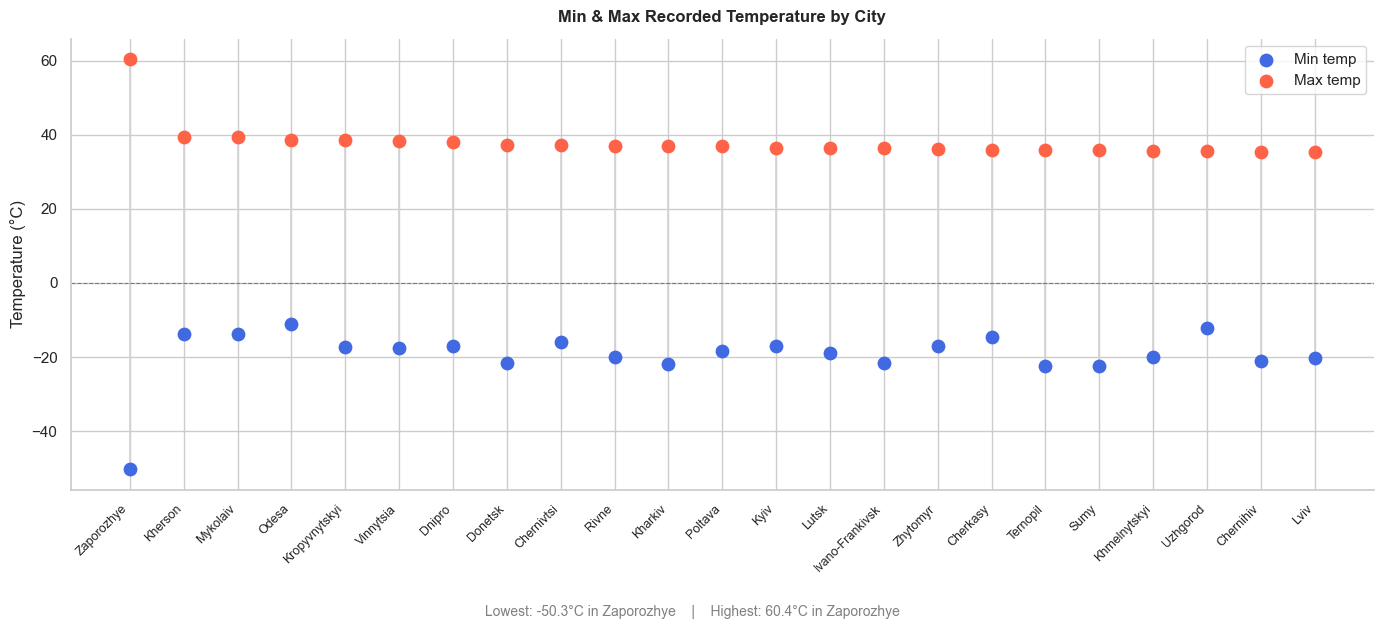

In [26]:
weather_vis = weather.copy()

min_temp = weather_vis.groupby("city")["temp"].min().reset_index().rename(columns={"temp": "min_temp"})
max_temp = weather_vis.groupby("city")["temp"].max().reset_index().rename(columns={"temp": "max_temp"})
merged   = min_temp.merge(max_temp, on="city").sort_values("max_temp", ascending=False)

coldest_city = merged.loc[merged["min_temp"].idxmin(), "city"]
coldest_temp = merged["min_temp"].min()
hottest_city = merged.loc[merged["max_temp"].idxmax(), "city"]
hottest_temp = merged["max_temp"].max()

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(merged))
ax.scatter(x, merged["min_temp"], color="royalblue", s=80, zorder=3, label="Min temp")
ax.scatter(x, merged["max_temp"], color="tomato",    s=80, zorder=3, label="Max temp")

for i, row in enumerate(merged.itertuples()):
    ax.plot([i, i], [row.min_temp, row.max_temp], color="lightgray", linewidth=1.2, zorder=2)

ax.set_xticks(list(x))
ax.set_xticklabels(
    merged["city"].str.replace(",Ukraine", "", regex=False),
    rotation=45, ha="right", fontsize=9
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Min & Max Recorded Temperature by City", fontweight="bold", pad=12)
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5, -0.04,
    f"Lowest: {coldest_temp:.1f}°C in {coldest_city}    |    "
    f"Highest: {hottest_temp:.1f}°C in {hottest_city}",
    ha="center", fontsize=10, color="gray"
)

plt.tight_layout()
plt.show()

In [27]:
TEMP_MIN, TEMP_MAX = -35, 45

anomalies = weather[(weather['temp'] > TEMP_MAX) | (weather['temp'] < TEMP_MIN)]
print(f'Anomalous temperature rows found: {len(anomalies)}')
if len(anomalies) > 0:
    print(anomalies[['city','datetime','temp']].to_string())

weather.loc[(weather['temp'] > TEMP_MAX) | (weather['temp'] < TEMP_MIN), 'temp'] = np.nan

weather['temp'] = (
    weather.groupby('city', observed=True)['temp']
    .transform(lambda x: x.interpolate(method='linear'))
)

remaining_anom = weather[(weather['temp'] > TEMP_MAX) | (weather['temp'] < TEMP_MIN)]
print(f'Anomalies remaining after fix: {len(remaining_anom)}')

Anomalous temperature rows found: 2
              city            datetime  temp
558461  Zaporozhye 2022-07-03 21:00:00  60.4
560933  Zaporozhye 2022-10-14 21:00:00 -50.3
Anomalies remaining after fix: 0


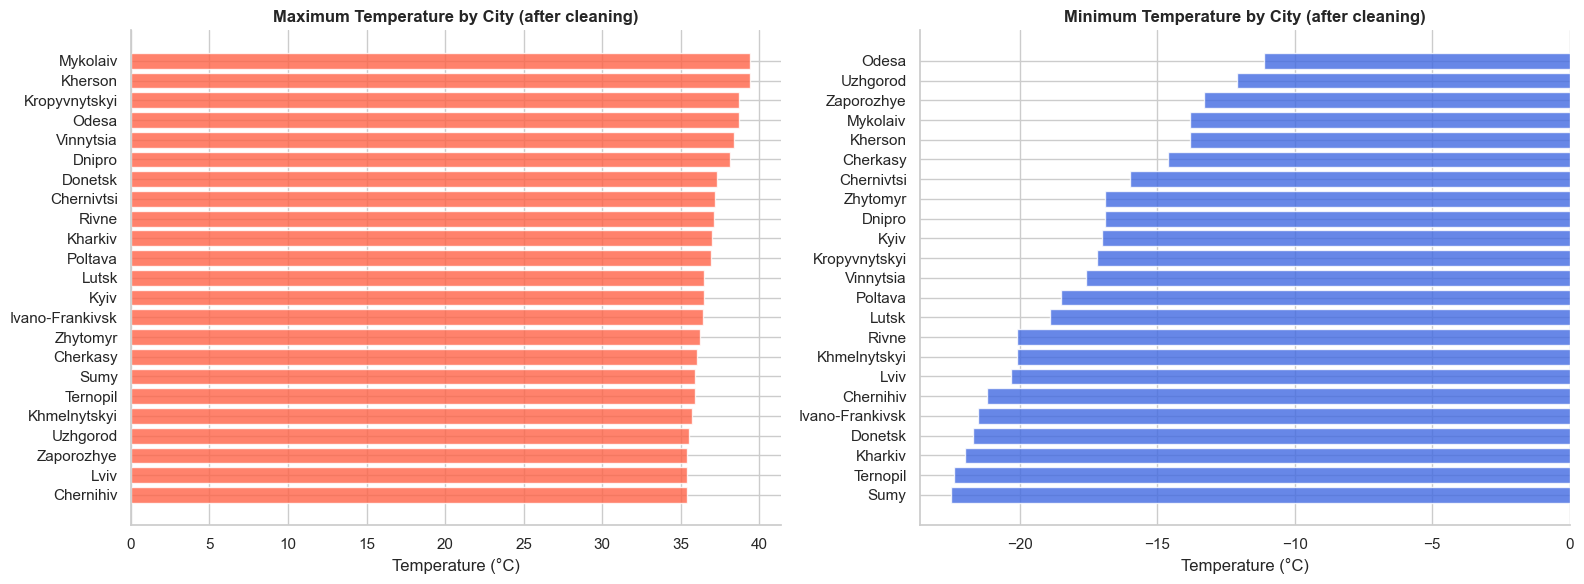

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, agg, label, color in [
    (axes[0], 'max', 'Maximum', 'tomato'),
    (axes[1], 'min', 'Minimum', 'royalblue')
]:
    val = weather.groupby('city', observed=True)['temp'].agg(agg).sort_values().reset_index()
    val['city'] = val['city'].str.replace(',Ukraine','',regex=False)
    ax.barh(val['city'], val['temp'], color=color, alpha=0.8)
    ax.set_title(f'{label} Temperature by City (after cleaning)', fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 7. Feature Engineering

Tree-based models see one row at a time — a single hourly snapshot with no memory
of what came before. Feature engineering encodes temporal context, atmospheric
dynamics, and categorical conditions directly into each row so the model can detect
patterns across time without any built-in memory.

The following features are created across 7 subsections:

| Group | Created features |
|---|---|
| **7.1 Temporal** | `year`, `month`, `day`, `weekday`, `hour`, `is_winter`, `is_spring`, `is_summer`, `is_autumn` |
| **7.2 Temperature** | `rolling_temp_24h`, `temp_change_24h` |
| **7.3 Precipitation** | `rolling_precip_24h`, `precip_sum_6h`, `is_rainy_hour`, `is_heavy_rain` |
| **7.4 Wind** | `wind_intensity`, `gust_ratio`, `is_high_wind`, `max_gust_6h`, `winddir_sin`, `winddir_cos` |
| **7.5 Pressure** | `pressure_change_3h`, `pressure_change_24h`, `sharp_pressure_drop`, `pressure_min_24h` |
| **7.6 Conditions** | `is_snow`, `is_rain`, `is_freezing_precip`, `is_fog`, `is_overcast`, `is_partly_cloudy`, `is_clear`, `is_windy_category` |
| **7.7 Moon** | `moon_illumination`, `is_bright_night` |

All rolling and lag features are computed **independently per city** via `groupby`
to prevent cross-city contamination. Wind direction is projected onto a unit circle
via `winddir_sin` / `winddir_cos`. Binary season flags replace the raw `season`
string, which is dropped after encoding.

### 7.1 Basic time periods

In [29]:
weather['year']    = weather['datetime'].dt.year
weather['month']   = weather['datetime'].dt.month
weather['day']     = weather['datetime'].dt.day
weather['weekday'] = weather['datetime'].dt.weekday
weather['hour']    = weather['datetime'].dt.hour

def get_season(month):
    if month in [12, 1, 2]:  return 'winter'
    elif month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    else:                    return 'autumn'

weather['season']    = weather['month'].apply(get_season)

# Binary season flags — one-hot encoded for direct use in tree-based models
weather['is_winter'] = (weather['season'] == 'winter').astype('int8')
weather['is_spring'] = (weather['season'] == 'spring').astype('int8')
weather['is_summer'] = (weather['season'] == 'summer').astype('int8')
weather['is_autumn'] = (weather['season'] == 'autumn').astype('int8')

print('Temporal features done.')

Temporal features done.


In [30]:
weather.head(5)

,city,datetime,temp,humidity,dew,pressure,precip,precipprob,cloudcover,snow,windspeed,winddir,windgust,visibility,day_sunrise,day_sunset,day_conditions,conditions,icon,day_moonphase,date,hours,year,month,day,weekday,hour,season,is_winter,is_spring,is_summer,is_autumn
0,Cherkasy,2022-02-24 00:00:00,0.9,75.73,-2.9,1020.0,0.0,0.0,89.0,0.0,4.0,132.0,7.2,24.1,06:44:41,17:26:05,Partially cloudy,Partially cloudy,partly-cloudy-night,0.77,2022-02-24,0,2022,2,24,3,0,winter,1,0,0,0
1,Cherkasy,2022-02-24 01:00:00,0.6,77.96,-2.8,1020.0,0.0,0.0,71.1,0.0,3.6,147.9,6.5,24.1,06:44:41,17:26:05,Partially cloudy,Partially cloudy,partly-cloudy-night,0.77,2022-02-24,1,2022,2,24,3,1,winter,1,0,0,0
2,Cherkasy,2022-02-24 02:00:00,0.4,82.08,-2.3,1020.0,0.0,0.0,95.4,0.0,3.2,198.2,8.3,24.1,06:44:41,17:26:05,Partially cloudy,Overcast,cloudy,0.77,2022-02-24,2,2022,2,24,3,2,winter,1,0,0,0
3,Cherkasy,2022-02-24 03:00:00,0.2,83.28,-2.3,1020.0,0.0,0.0,74.6,0.0,2.9,202.3,5.0,24.1,06:44:41,17:26:05,Partially cloudy,Partially cloudy,partly-cloudy-night,0.77,2022-02-24,3,2022,2,24,3,3,winter,1,0,0,0
4,Cherkasy,2022-02-24 04:00:00,0.0,83.87,-2.4,1021.0,0.0,0.0,67.8,0.0,2.9,203.6,5.0,24.1,06:44:41,17:26:05,Partially cloudy,Partially cloudy,partly-cloudy-night,0.77,2022-02-24,4,2022,2,24,3,4,winter,1,0,0,0


### 7.2 Temperature features

Raw hourly temperature alone tells the model what the weather is like right now, but
not whether conditions are changing. These three features capture the dynamic component:

- **`rolling_temp_24h`** — the 24-hour rolling mean per city. Represents the recent
  temperature baseline, smoothing out short-term noise.
- **`temp_change_24h`** — difference between the current hour and the same hour 24 hours
  ago. Captures how much the temperature has shifted over a full day cycle.

All three are computed independently per city to avoid cross-city contamination.


In [31]:
weather = weather.sort_values(['city', 'datetime']).reset_index(drop=True)

weather['rolling_temp_24h'] = (
    weather.groupby('city', observed=True)['temp']
    .transform(lambda x: x.rolling(24, min_periods=1).mean())
)
weather['temp_change_24h'] = (
    weather.groupby('city', observed=True)['temp']
    .transform(lambda x: x.diff(24))
)

print('Temperature features done.')

Temperature features done.


In [32]:
weather['rolling_temp_24h'] = weather['rolling_temp_24h'].fillna(0)
weather['temp_change_24h'] = weather['temp_change_24h'].fillna(0)

### 7.3 Precipitation Features

A single hourly precipitation value captures only the current moment. These features
extend that signal across time and add binary flags for quick pattern detection:

- **`rolling_precip_24h`** — cumulative precipitation over the past 24 hours. Captures
  sustained wet periods that a single hourly reading would miss entirely.
- **`precip_sum_6h`** — cumulative precipitation over the past 6 hours. A shorter window
  that detects active rain spells without diluting the signal across a full day.
- **`is_rainy_hour`** — binary flag, 1 if any precipitation was recorded that hour.
- **`is_heavy_rain`** — binary flag, 1 if precipitation exceeded 2.5mm — a standard
  meteorological threshold for heavy rain.

The two rolling windows complement each other: `precip_sum_6h` catches short intense
bursts, `rolling_precip_24h` captures prolonged wet conditions.

In [33]:
weather['rolling_precip_24h'] = (
    weather.groupby('city', observed=True)['precip']
    .transform(lambda x: x.rolling(24, min_periods=1).sum())
)
weather['precip_sum_6h'] = (
    weather.groupby('city', observed=True)['precip']
    .transform(lambda x: x.rolling(6, min_periods=1).sum())
)
weather['is_rainy_hour']  = (weather['precip'] > 0).astype('int8')
weather['is_heavy_rain']  = (weather['precip'] > 2.5).astype('int8')

print('Precipitation features done.')

Precipitation features done.


### 7.4 Wind Features

Wind speed alone is insufficient — direction is circular and a single speed value
carries no information about turbulence or sustained stormy conditions. These features
encode wind intensity, gustiness, and direction in a model-ready format.

- **`wind_intensity`** — sum of wind speed and gust as a single combined magnitude
  signal.
- **`gust_ratio`** — gust divided by sustained wind speed. Measures turbulence: a
  high ratio indicates sharp, unpredictable bursts even when average speed is low.
- **`is_high_wind`** — binary flag, 1 if wind gust exceeds 50 km/h. A standard
  meteorological threshold for storm-level conditions.
- **`max_gust_6h`** — maximum gust recorded in the past 6 hours per city. Captures
  sustained stormy periods rather than isolated single-hour spikes.
- **`winddir_sin` / `winddir_cos`** — cyclical encoding of wind direction (0–360°).
  Degrees are circular — 359° and 1° are nearly identical but numerically far apart.
  Sin/cos projection maps direction onto a unit circle, preserving true angular
  distance for the model.

In [34]:
weather['windgust'] = weather['windgust'].fillna(weather['windspeed'])

weather['wind_intensity'] = weather['windspeed'] + weather['windgust']

weather['gust_ratio'] = np.where(
    weather['windspeed'] > 0,
    weather['windgust'] / weather['windspeed'],
    1.0  
)

weather['is_high_wind'] = (weather['windgust'] > 50).astype('int8')

weather['max_gust_6h'] = (
    weather.groupby('city', observed=True)['windgust']
    .transform(lambda x: x.rolling(6, min_periods=1).max())
)

if 'winddir' in weather.columns:
    rads = np.deg2rad(weather['winddir'])
    weather['winddir_sin'] = np.sin(rads)
    weather['winddir_cos'] = np.cos(rads)

print('Wind features done.')
weather[['city', 'windspeed', 'windgust', 'winddir_sin', 'winddir_cos', 'max_gust_6h']].head()

Wind features done.


,city,windspeed,windgust,winddir_sin,winddir_cos,max_gust_6h
0,Cherkasy,4.0,7.2,0.743145,-0.669131,7.2
1,Cherkasy,3.6,6.5,0.531399,-0.847122,7.2
2,Cherkasy,3.2,8.3,-0.312335,-0.949972,8.3
3,Cherkasy,2.9,5.0,-0.379456,-0.925210,8.3
4,Cherkasy,2.9,5.0,-0.400349,-0.916363,8.3


### 7.5 Pressure Features

Atmospheric pressure is most informative not as an absolute value but as a rate of
change. A sudden drop signals an approaching low-pressure system — historically
associated with deteriorating weather conditions. These features encode both the
short-term and daily pressure dynamics that a raw hourly reading cannot capture alone.

- **`pressure_change_3h`** — pressure delta over the past 3 hours. Detects rapid
  short-term drops that precede incoming fronts.
- **`pressure_change_24h`** — pressure delta over the past 24 hours. Captures
  slower but sustained pressure trends across a full day.
- **`sharp_pressure_drop`** — binary flag, 1 if the 24h pressure drop exceeds 5 hPa.
  A standard meteorological threshold for significant atmospheric instability.
- **`pressure_min_24h`** — the lowest pressure recorded in the past 24 hours per city.
  Captures the depth of a low-pressure trough rather than just the current reading.

In [35]:
weather['pressure_change_3h'] = (
    weather.groupby('city', observed=True)['pressure']
    .transform(lambda x: x.diff(3))
)
weather['pressure_change_24h'] = (
    weather.groupby('city', observed=True)['pressure']
    .transform(lambda x: x.diff(24))
)
weather['sharp_pressure_drop'] = (weather['pressure_change_24h'] < -5).astype('int8')
weather['pressure_min_24h'] = (
    weather.groupby('city', observed=True)['pressure']
    .transform(lambda x: x.rolling(24, min_periods=1).min())
)

print('Pressure features done.')

Pressure features done.


In [36]:
weather['pressure_change_3h'] = weather['pressure_change_3h'].fillna(0)
weather['pressure_change_24h'] = weather['pressure_change_24h'].fillna(0)

### 7.6 Visibility Features

The `conditions`, `day_conditions`, and `icon` columns contain free-text weather
descriptions. Rather than encoding them directly — which would produce a sparse,
high-cardinality representation — they are parsed into eight binary flags covering
the meteorologically relevant categories for the modeling task.

Each flag is derived by searching all three columns simultaneously using a
keyword pattern match, ensuring no condition is missed regardless of which column
captured it for a given row.

- **`is_snow`** — snow or ice present
- **`is_rain`** — rain or drizzle present
- **`is_freezing_precip`** — freezing rain or freezing drizzle
- **`is_fog`** — fog or mist conditions
- **`is_overcast`** — overcast or cloudy conditions, also triggered when
  `cloudcover ≥ 90%` regardless of text label
- **`is_partly_cloudy`** — partially cloudy conditions
- **`is_clear`** — clear sky, only set when neither snow nor rain is present
  to avoid false positives from ambiguous condition strings
- **`is_windy_category`** — derived from `icon == 'wind'` rather than text,
  as wind is encoded categorically in the icon column

In [37]:
target_cols = ['conditions', 'day_conditions', 'icon']

def check_weather(keywords):
    """Search for keywords across all three condition columns simultaneously."""
    pattern = '|'.join(keywords)
    return (
        weather[target_cols]
        .apply(lambda x: x.str.contains(pattern, case=False, na=False))
        .any(axis=1)
        .astype(int)
    )

weather['is_snow']            = check_weather(['Snow', 'Ice'])
weather['is_rain']            = check_weather(['Rain', 'Drizzle'])
weather['is_freezing_precip'] = check_weather(['Freezing'])
weather['is_fog']             = check_weather(['Fog', 'fog'])
weather['is_overcast']        = (
    check_weather(['Overcast', 'cloudy']) |
    (weather['cloudcover'] >= 90)
).astype(int)
weather['is_partly_cloudy']   = check_weather(['Partially cloudy', 'partly-cloudy-day'])
weather['is_clear']           = (
    check_weather(['Clear', 'clear-day']) &
    (weather['is_snow'] == 0) &
    (weather['is_rain'] == 0)
).astype(int)
weather['is_windy_category']  = (weather['icon'] == 'wind').astype(int)

print('Categorical condition flags done.')

Categorical condition flags done.


In [38]:
weather = weather.drop(columns = target_cols)

### 7.7 Moonphase Features

Based on the hypothesis that nighttime visibility conditions may correlate with
air raid timing — darker nights reduce visual detection risk. `moonphase` (0 = new
moon, 0.5 = full moon, 1 = new moon again) is converted into two actionable features:

- **`moon_illumination`** — approximates the illuminated fraction of the lunar disc
  using `1 - |2 * moonphase - 1|`. Produces a 0–1 scale where 0 is a completely
  dark new moon and 1 is a full moon.
- **`is_bright_night`** — binary flag, 1 if it is nighttime (`is_daylight == 0`)
  and moon illumination exceeds 0.5. Captures hours where the moon provides
  meaningful ambient light.

Note: this is a weak hypothesis — attack timing is driven by military logistics
rather than lunar cycles. The feature is inexpensive to include and will be
evaluated automatically during feature importance analysis at the modeling stage.

In [39]:
if 'day_moonphase' in weather.columns:
    weather['moon_illumination'] = 1 - np.abs(2 * weather['day_moonphase'] - 1)

    weather['is_bright_night'] = (weather['moon_illumination'] > 0.5).astype('int8')
    print('Moon features done.')
else:
    print('moonphase column not found — skipped.')

Moon features done.


In [40]:
print(f'Total features after engineering: {weather.shape[1]}')
print('\nAll columns:')
print(weather.columns.tolist())

Total features after engineering: 55

All columns:
['city', 'datetime', 'temp', 'humidity', 'dew', 'pressure', 'precip', 'precipprob', 'cloudcover', 'snow', 'windspeed', 'winddir', 'windgust', 'visibility', 'day_sunrise', 'day_sunset', 'day_moonphase', 'date', 'hours', 'year', 'month', 'day', 'weekday', 'hour', 'season', 'is_winter', 'is_spring', 'is_summer', 'is_autumn', 'rolling_temp_24h', 'temp_change_24h', 'rolling_precip_24h', 'precip_sum_6h', 'is_rainy_hour', 'is_heavy_rain', 'wind_intensity', 'gust_ratio', 'is_high_wind', 'max_gust_6h', 'winddir_sin', 'winddir_cos', 'pressure_change_3h', 'pressure_change_24h', 'sharp_pressure_drop', 'pressure_min_24h', 'is_snow', 'is_rain', 'is_freezing_precip', 'is_fog', 'is_overcast', 'is_partly_cloudy', 'is_clear', 'is_windy_category', 'moon_illumination', 'is_bright_night']


In [41]:
weather.head(5)

,city,datetime,temp,humidity,dew,pressure,precip,precipprob,cloudcover,snow,windspeed,winddir,windgust,visibility,day_sunrise,day_sunset,day_moonphase,date,hours,year,month,day,weekday,hour,season,is_winter,is_spring,is_summer,is_autumn,rolling_temp_24h,temp_change_24h,rolling_precip_24h,precip_sum_6h,is_rainy_hour,is_heavy_rain,wind_intensity,gust_ratio,is_high_wind,max_gust_6h,winddir_sin,winddir_cos,pressure_change_3h,pressure_change_24h,sharp_pressure_drop,pressure_min_24h,is_snow,is_rain,is_freezing_precip,is_fog,is_overcast,is_partly_cloudy,is_clear,is_windy_category,moon_illumination,is_bright_night
0,Cherkasy,2022-02-24 00:00:00,0.9,75.73,-2.9,1020.0,0.0,0.0,89.0,0.0,4.0,132.0,7.2,24.1,06:44:41,17:26:05,0.77,2022-02-24,0,2022,2,24,3,0,winter,1,0,0,0,0.900000,0.0,0.0,0.0,0,0,11.2,1.800000,0,7.2,0.743145,-0.669131,0.0,0.0,0,1020.0,0,0,0,0,1,1,0,0,0.46,0
1,Cherkasy,2022-02-24 01:00:00,0.6,77.96,-2.8,1020.0,0.0,0.0,71.1,0.0,3.6,147.9,6.5,24.1,06:44:41,17:26:05,0.77,2022-02-24,1,2022,2,24,3,1,winter,1,0,0,0,0.750000,0.0,0.0,0.0,0,0,10.1,1.805556,0,7.2,0.531399,-0.847122,0.0,0.0,0,1020.0,0,0,0,0,1,1,0,0,0.46,0
2,Cherkasy,2022-02-24 02:00:00,0.4,82.08,-2.3,1020.0,0.0,0.0,95.4,0.0,3.2,198.2,8.3,24.1,06:44:41,17:26:05,0.77,2022-02-24,2,2022,2,24,3,2,winter,1,0,0,0,0.633333,0.0,0.0,0.0,0,0,11.5,2.593750,0,8.3,-0.312335,-0.949972,0.0,0.0,0,1020.0,0,0,0,0,1,1,0,0,0.46,0
3,Cherkasy,2022-02-24 03:00:00,0.2,83.28,-2.3,1020.0,0.0,0.0,74.6,0.0,2.9,202.3,5.0,24.1,06:44:41,17:26:05,0.77,2022-02-24,3,2022,2,24,3,3,winter,1,0,0,0,0.525000,0.0,0.0,0.0,0,0,7.9,1.724138,0,8.3,-0.379456,-0.925210,0.0,0.0,0,1020.0,0,0,0,0,1,1,0,0,0.46,0
4,Cherkasy,2022-02-24 04:00:00,0.0,83.87,-2.4,1021.0,0.0,0.0,67.8,0.0,2.9,203.6,5.0,24.1,06:44:41,17:26:05,0.77,2022-02-24,4,2022,2,24,3,4,winter,1,0,0,0,0.420000,0.0,0.0,0.0,0,0,7.9,1.724138,0,8.3,-0.400349,-0.916363,1.0,0.0,0,1020.0,0,0,0,0,1,1,0,0,0.46,0


---

## 8. Visual Analysis

### Section A — General Weather Patterns

**A1 — Distribution of Hourly Temperature** confirms the bimodal structure of
temperature across the full dataset. The dominant cold peak sits at 0°C and a broader
warm hump spans 15–22°C, separated by a shallow valley around 8–10°C. Mean (10.7°C)
and median (10.2°C) fall almost identically in this valley — a statistical artifact of
the bimodal shape rather than a true "typical" temperature. The clean tails with no
values beyond ±35°C confirm that anomaly correction in Step 6 was successful.

**A2 — Temperature Distribution by Season** shows four well-separated seasonal
distributions with minimal overlap between adjacent groups. Winter is centered near
0°C with the widest spread and the longest lower whisker (down to −22°C), reflecting
genuine cold snaps. Summer is the most compact season — tight IQR around 20–25°C with
only a handful of outliers near 38°C. Spring and autumn are near-symmetric mirror
images of each other, both centered around 10°C. The clean separation confirms that
binary season flags (`is_winter`, `is_summer` etc.) carry strong discriminative signal
for the model.

**A3 — Correlation Matrix on Cleaned Data** shows the same dominant relationships
seen in the raw data, now with `gust_ratio` added as a new engineered feature.
`temp` ↔ `dew` remains the strongest pair at **+0.86**, and `temp` ↔ `humidity`
at **−0.58** is unchanged. Notably, `gust_ratio` shows near-zero correlation with
every other variable — confirming it captures a unique turbulence signal independent
of absolute wind speed, pressure, or temperature.

**A4 — Average Hourly Precipitation by City and Month** reveals a strong geographic
split. The vast majority of cities record very low average hourly precipitation
(0.02–0.14mm) with no pronounced seasonal pattern. Zaporizhzhia is the clear
outlier — it dominates the heatmap with values an order of magnitude higher than
any other city, peaking at **0.80mm** in May and remaining elevated from March
through October. This is almost certainly a data artefact from the sensor anomalies
identified in section 2.2 rather than a genuine climatological difference, and is
worth flagging before the merge step.

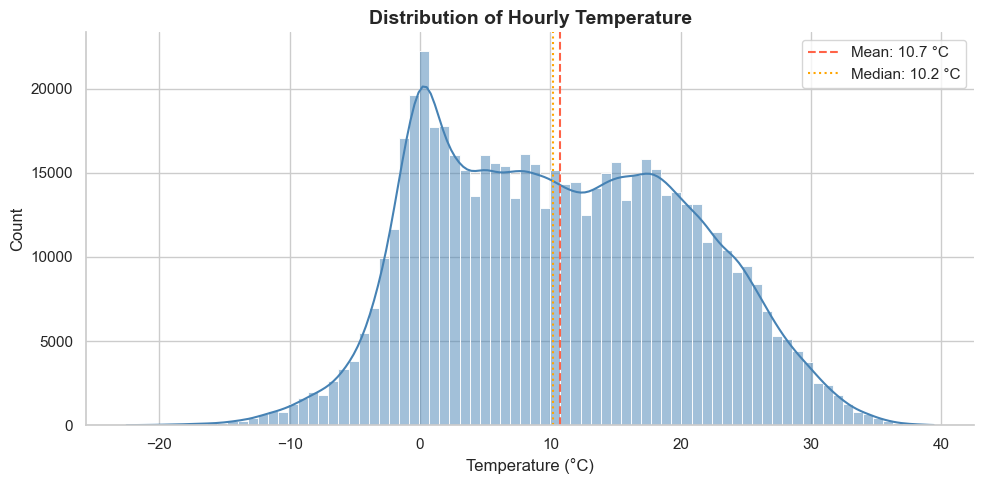

In [42]:
# A1 — Distribution of Hourly Temperature
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(weather['temp'], bins=80, kde=True, color='steelblue', ax=ax)
ax.axvline(weather['temp'].mean(),   color='tomato', linestyle='--',
           label=f"Mean: {weather['temp'].mean():.1f} °C")
ax.axvline(weather['temp'].median(), color='orange', linestyle=':',
           label=f"Median: {weather['temp'].median():.1f} °C")
ax.set_title('Distribution of Hourly Temperature', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Count')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_30896\1620128214.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weather, x='season', y='temp',


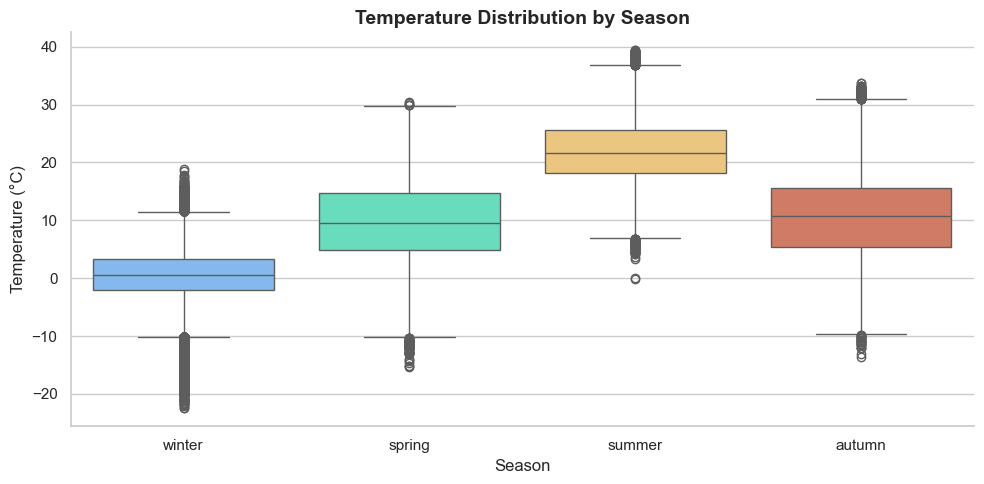

In [43]:
# A2 — Temperature Distribution by Season
season_order   = ['winter', 'spring', 'summer', 'autumn']
season_palette = {'winter':'#74b9ff','spring':'#55efc4','summer':'#fdcb6e','autumn':'#e17055'}

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=weather, x='season', y='temp',
            order=season_order, palette=season_palette, ax=ax)
ax.set_title('Temperature Distribution by Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Temperature (°C)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

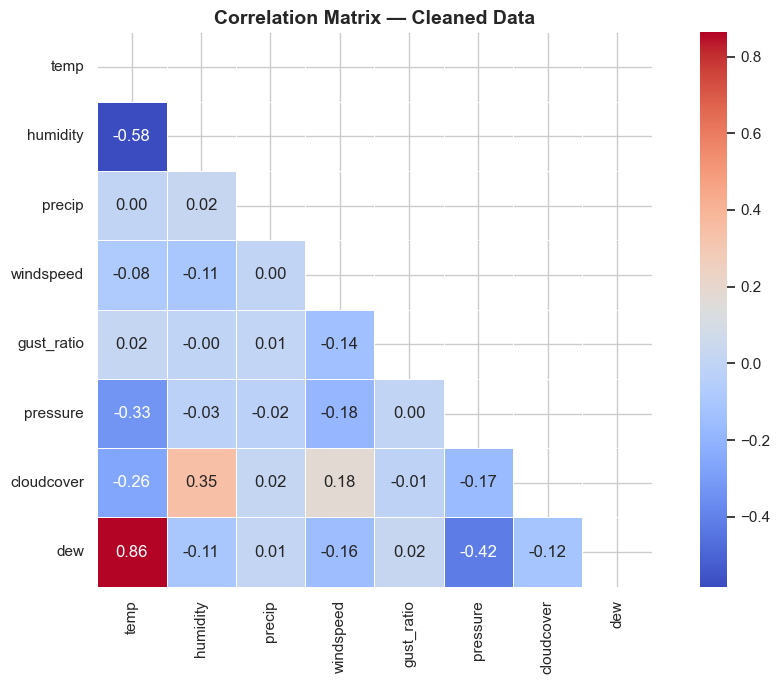

In [44]:
# A3 — Correlation Matrix on Cleaned Data
num_cols = ['temp','humidity','precip','windspeed','gust_ratio','pressure','cloudcover']
if 'dew' in weather.columns:
    num_cols.append('dew')
corr = weather[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5, ax=ax, mask=mask)
ax.set_title('Correlation Matrix — Cleaned Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

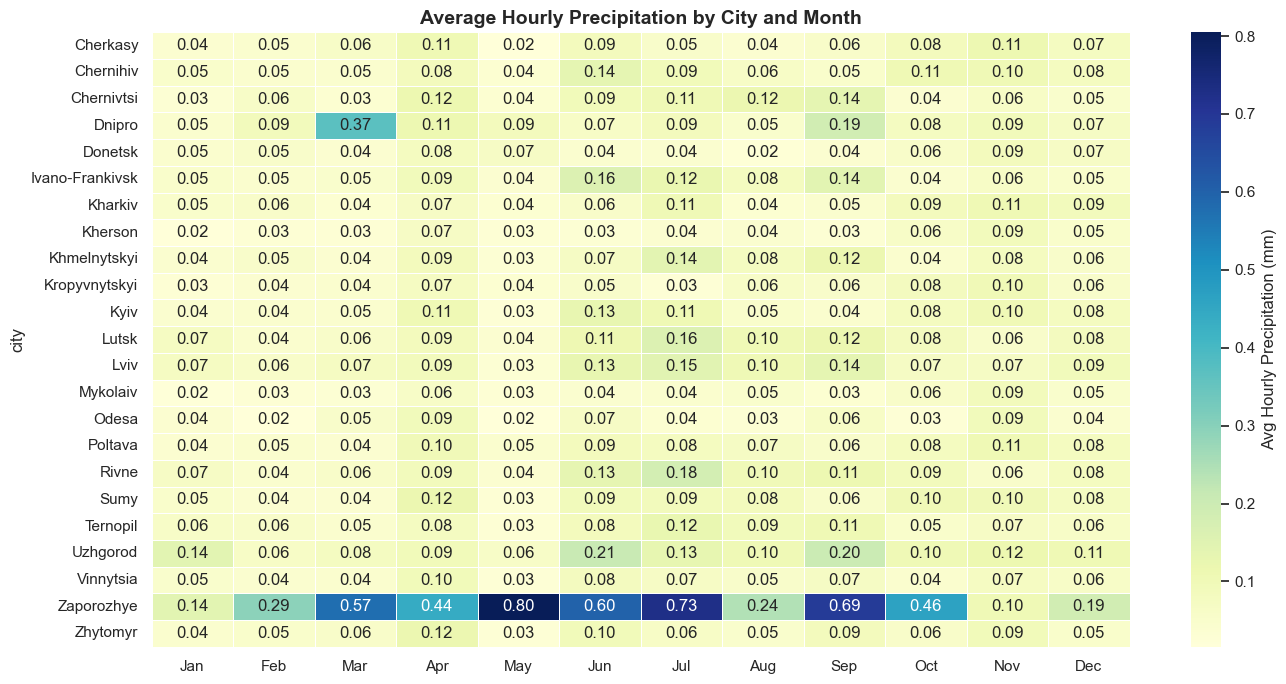

In [45]:
# A4 — Average Hourly Precipitation by City and Month
precip_pivot = weather.pivot_table(index='city', columns='month', values='precip', aggfunc='mean')
precip_pivot.index = precip_pivot.index.str.replace(',Ukraine','',regex=False)
precip_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(precip_pivot, cmap='YlGnBu', annot=True, fmt='.2f',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Avg Hourly Precipitation (mm)'})
ax.set_title('Average Hourly Precipitation by City and Month', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### Section B — Features Relevant for Alarm Prediction

**B1 — Average Temperature by City and Hour of Day** — heatmap of mean hourly
temperature per city. Confirms a consistent diurnal cycle across all 23 cities:
peak at 14–16h, trough at 4–6h. Eastern cities show slightly wider amplitude.

**B2 — 7-Day Rolling Pressure by City** — smoothed pressure trends for Kyiv,
Kharkiv, Odesa, and Lviv over three years. All four cities move in sync —
pressure is a national-scale signal. Clear seasonal oscillation: lower in winter,
stable in summer.

**B3 — 24h Temperature Change by City** — range plot of
`temp_change_24h` per city. Purple bar = IQR, grey line = P5–P95 extremes.
Eastern and inland cities show the widest ranges — highest day-to-day volatility.

**B4 — Wind Rose by Season** — polar chart of mean wind speed across 16
directional bins per season. Winter: stronger northerly and north-easterly winds.
Summer: lighter, more evenly distributed. Confirms why `winddir` needs sin/cos
encoding rather than raw degrees.

**B5 — Fog and Overcast % by Month and Year** — two line charts tracking
monthly fog and overcast hours per year. Fog peaks in October–December.
Overcast elevated from October through March. Patterns are consistent year to year.

**B6 — Weather Condition Flags by Month (Stacked Bar)** — monthly share of
hours flagged as snow, rain, freezing precip, fog, and overcast. Winter dominated
by snow and overcast; summer shifts to rain events. Shows clear seasonal
transitions between condition types.

**B7 — Sharp Pressure Drops by Month and Year** — monthly share of hours where
`sharp_pressure_drop == 1`. Drops peak in October–February across all years.
Most reliable frontal activity signal in the feature set.

**B8 — Moon Illumination vs Bright Night Hours by Month** — grouped bar of
average `moon_illumination` and `is_bright_night` share per month. Both stable
at ~50% across all months — confirms no seasonal bias is introduced by these
features.

**B9 — Average Cloud Cover by Year and Month** — heatmap of mean
`cloudcover` per year × month cell. Winter cells consistently darkest (70–85%).
Summer lighter (50–65%). Stable across all four years — no anomalous cells.

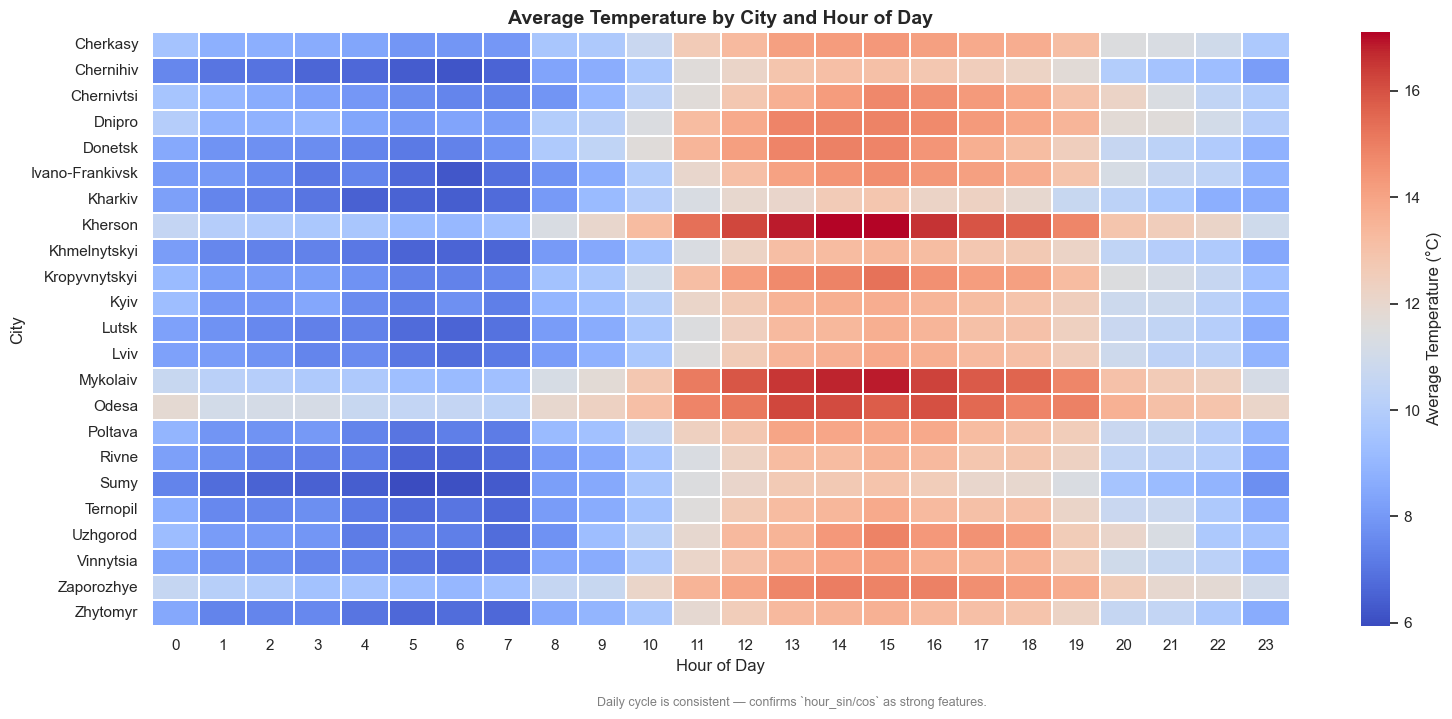

In [46]:
# B1 — Average Temperature by City and Hour of Day
pivot_city_hour = weather.pivot_table(index='city', columns='hour', values='temp', aggfunc='mean')
pivot_city_hour.index = pivot_city_hour.index.str.replace(',Ukraine','',regex=False)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot_city_hour, cmap='coolwarm', annot=False, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Average Temperature (°C)'})
ax.set_title('Average Temperature by City and Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('City')
fig.text(0.5, -0.02, 'Daily cycle is consistent — confirms `hour_sin/cos` as strong features.',
         ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

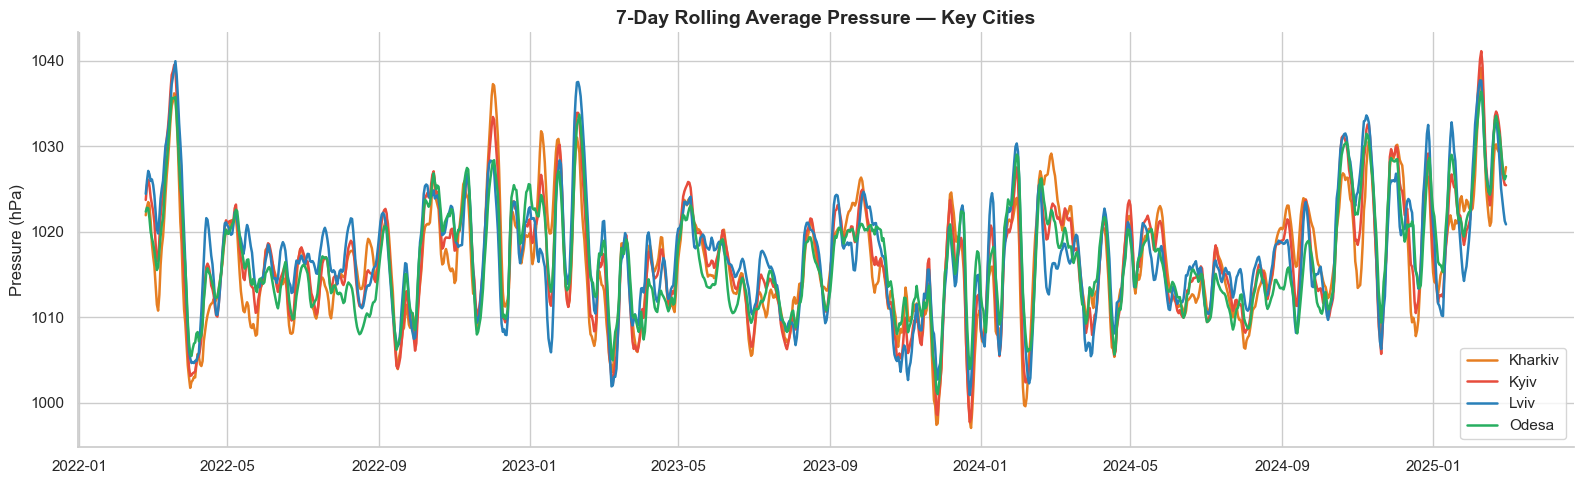

In [47]:
# B2 — 7-Day Rolling Pressure by City
selected = ['Kyiv','Kharkiv','Odesa','Lviv']
colors_p = {'Kyiv':'#e74c3c','Kharkiv':'#e67e22',
            'Odesa':'#27ae60','Lviv':'#2980b9'}

pressure_daily = (
    weather[weather['city'].isin(selected)]
    .groupby(['city','date'], observed=True)['pressure'].mean().reset_index()
)
pressure_daily['date'] = pd.to_datetime(pressure_daily['date'])

fig, ax = plt.subplots(figsize=(16, 5))
for city, grp in pressure_daily.groupby('city', observed=True):
    grp = grp.sort_values('date')
    smoothed = grp['pressure'].rolling(7, center=True, min_periods=1).mean()
    ax.plot(grp['date'], smoothed, label=city.replace(',Ukraine',''),
            color=colors_p[city], linewidth=1.8)
ax.set_title('7-Day Rolling Average Pressure — Key Cities', fontsize=14, fontweight='bold')
ax.set_ylabel('Pressure (hPa)')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

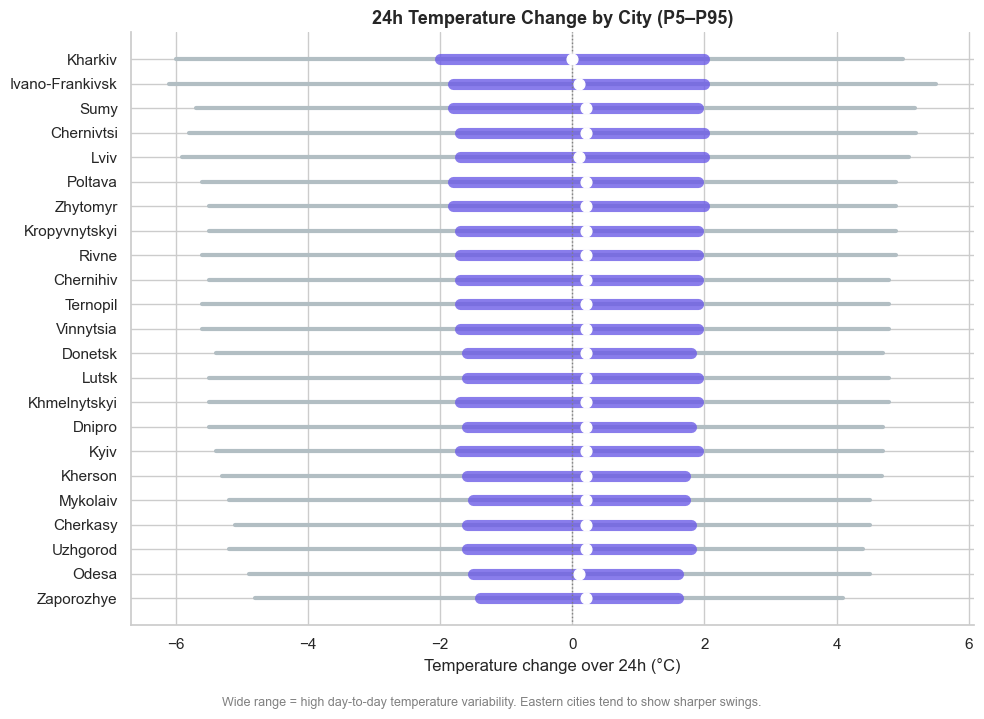

In [48]:
# B3 — 24h Temperature Change by City
change_stats = (
    weather.groupby('city', observed=True)['temp_change_24h']
    .describe(percentiles=[.05, .25, .75, .95])
    .reset_index()
)
change_stats['city'] = change_stats['city'].str.replace(',Ukraine', '', regex=False)
change_stats = change_stats.sort_values('std', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
for i, (_, row) in enumerate(change_stats.iterrows()):
    ax.plot([row['5%'], row['95%']], [i, i], color='#b2bec3', linewidth=3,
            solid_capstyle='round')
    ax.plot([row['25%'], row['75%']], [i, i], color='#6c5ce7', linewidth=8,
            solid_capstyle='round', alpha=0.8)
    ax.scatter([row['50%']], [i], color='white', s=60, zorder=5)
ax.set_yticks(range(len(change_stats)))
ax.set_yticklabels(change_stats['city'])
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_title('24h Temperature Change by City (P5–P95)', fontweight='bold', fontsize=13)
ax.set_xlabel('Temperature change over 24h (°C)')
ax.spines[['top', 'right']].set_visible(False)
fig.text(0.5, -0.02,
    'Wide range = high day-to-day temperature variability. '
    'Eastern cities tend to show sharper swings.',
    ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

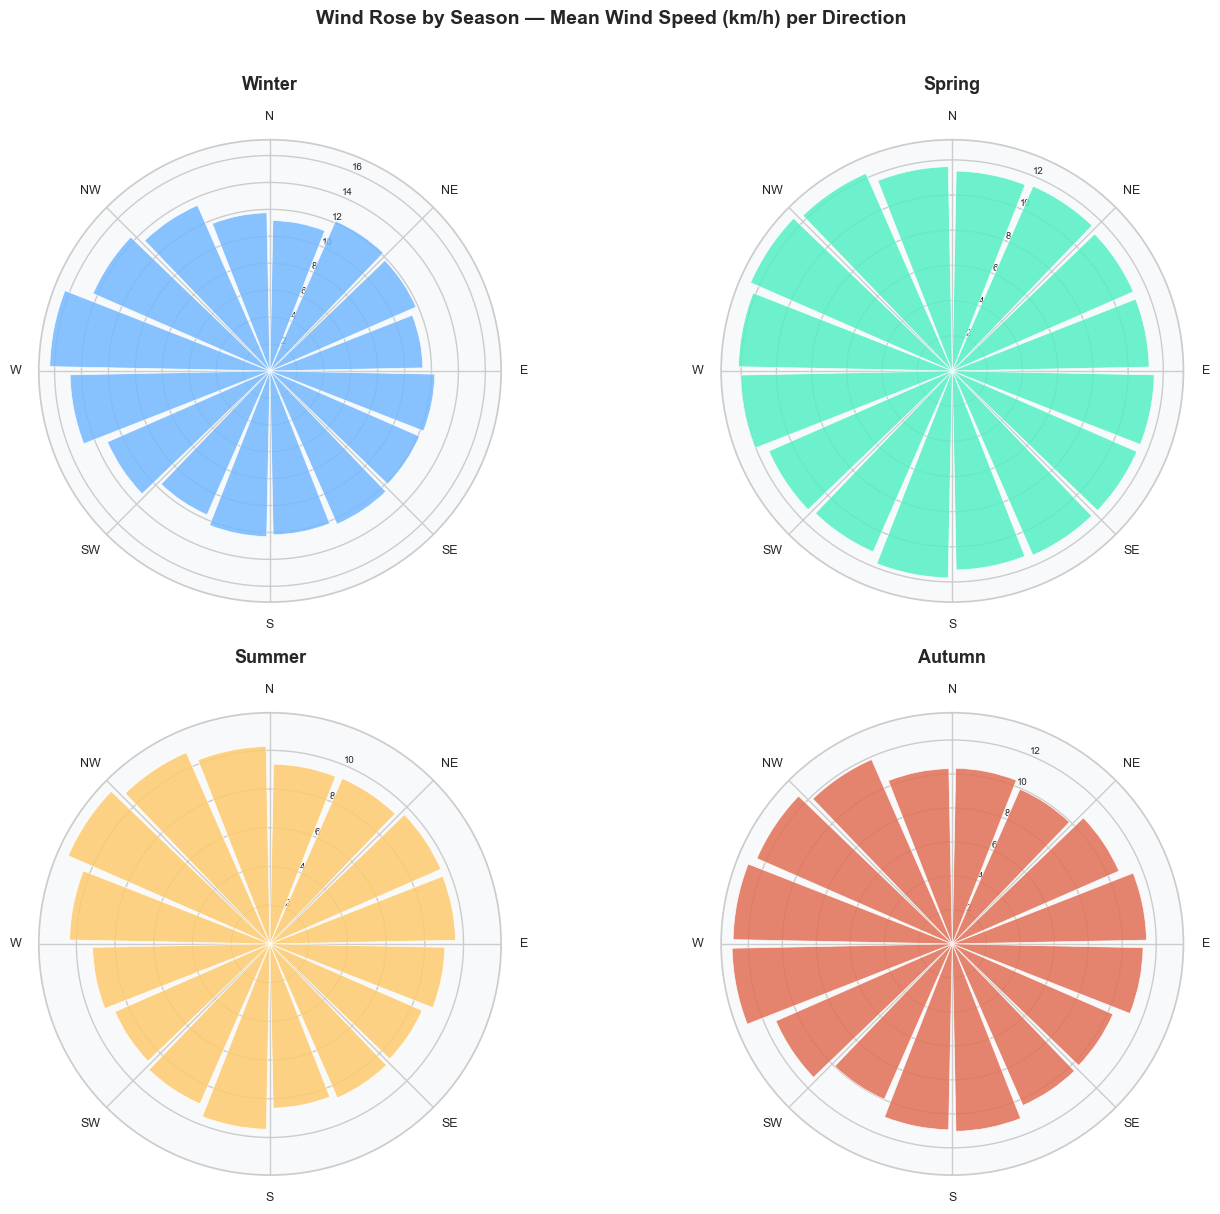

In [49]:
# B4 — Wind Rose by Season
import matplotlib.pyplot as plt
import numpy as np

seasons      = ['winter', 'spring', 'summer', 'autumn']
season_colors = {'winter':'#74b9ff', 'spring':'#55efc4',
                 'summer':'#fdcb6e', 'autumn':'#e17055'}

# 16 direction bins
n_bins    = 16
bin_edges = np.linspace(0, 360, n_bins + 1)
bin_centers = np.deg2rad((bin_edges[:-1] + bin_edges[1:]) / 2)
width     = 2 * np.pi / n_bins

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                         subplot_kw={'projection': 'polar'})
axes = axes.flatten()

for ax, season in zip(axes, seasons):
    subset = weather[weather['season'] == season].copy()

    # Bin wind directions
    subset['dir_bin'] = pd.cut(subset['winddir'], bins=bin_edges,
                               labels=False, include_lowest=True)

    # Mean wind speed per bin
    bin_speed = subset.groupby('dir_bin', observed=True)['windspeed'].mean().reindex(
        range(n_bins), fill_value=0
    ).values

    # Plot
    bars = ax.bar(bin_centers, bin_speed, width=width * 0.9,
                  color=season_colors[season], alpha=0.85, edgecolor='white',
                  linewidth=0.5)

    # Styling
    ax.set_theta_zero_location('N')   # North at top
    ax.set_theta_direction(-1)        # Clockwise
    ax.set_title(season.capitalize(), fontweight='bold', fontsize=13, pad=15)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_facecolor('#f8f9fa')

plt.suptitle('Wind Rose by Season — Mean Wind Speed (km/h) per Direction',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

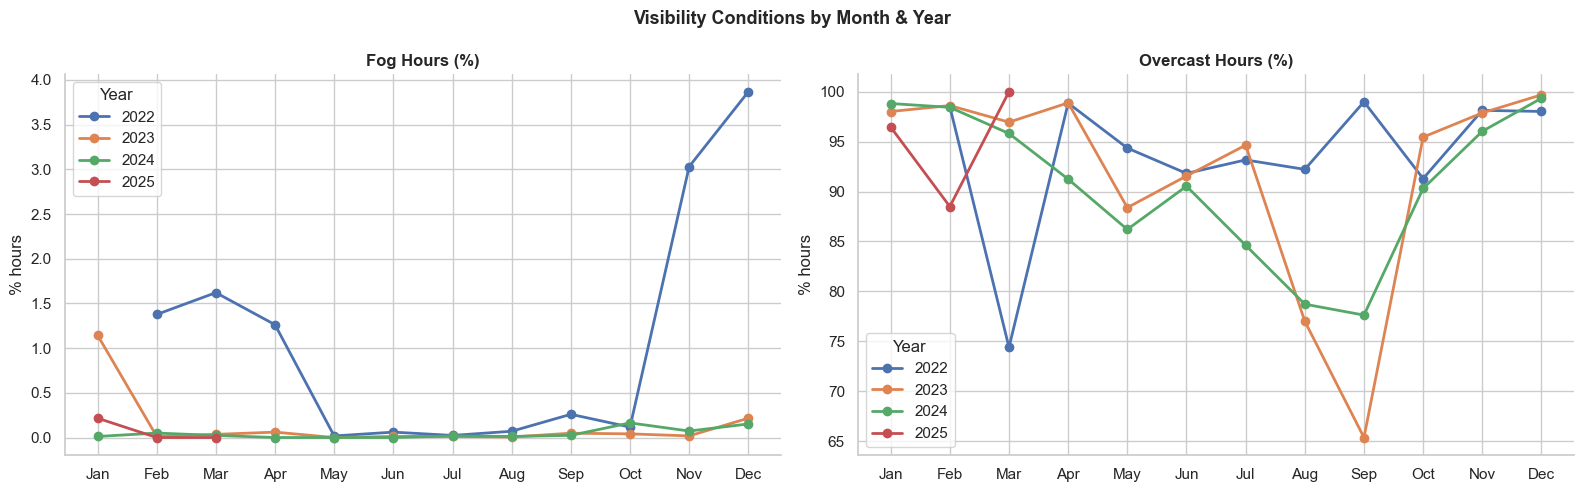

In [50]:
# B5 — Fog and Overcast % by month and year
vis_monthly = (
    weather.groupby(['year','month'], observed=True)
    .agg(fog_pct=('is_fog','mean'), overcast_pct=('is_overcast','mean'))
    .mul(100).reset_index()
)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title, color in zip(
    axes,
    ['fog_pct', 'overcast_pct'],
    ['Fog Hours (%)', 'Overcast Hours (%)'],
    ['#74b9ff', '#b2bec3']
):
    for year, grp in vis_monthly.groupby('year'):
        ax.plot(grp['month'], grp[col], marker='o', linewidth=2, label=str(year))
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_names)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('% hours')
    ax.legend(title='Year')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Visibility Conditions by Month & Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

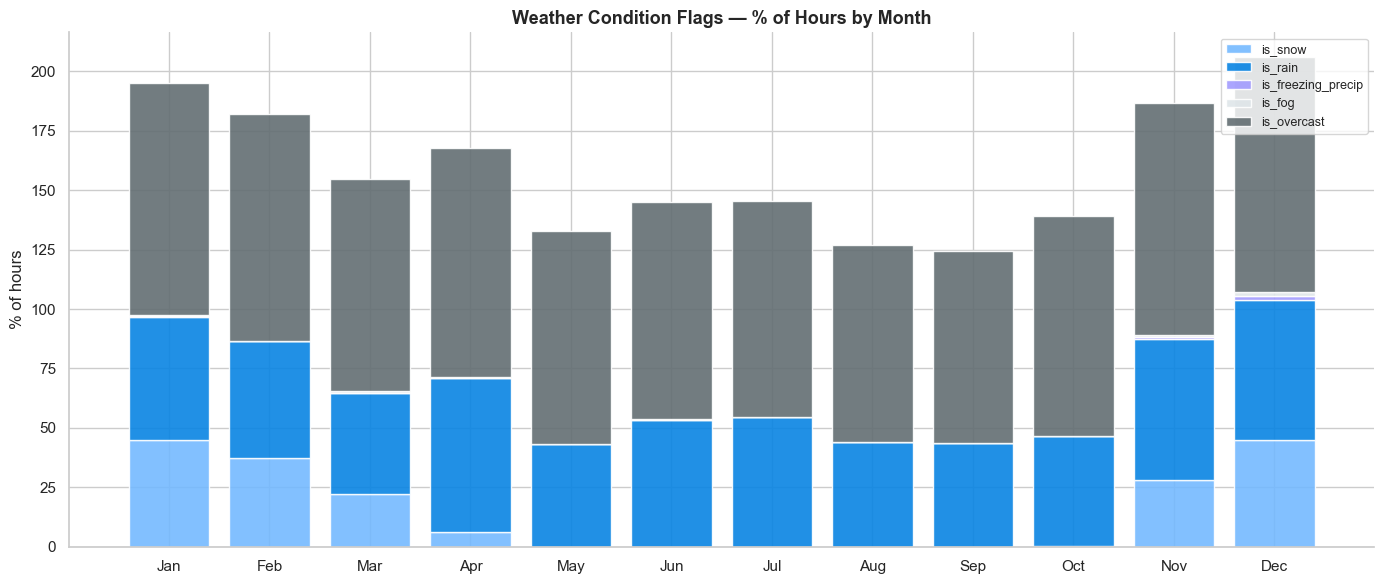

In [51]:
# B6 — Weather condition flags % by month (stacked bar)
cond_cols  = ['is_snow', 'is_rain', 'is_freezing_precip', 'is_fog', 'is_overcast']
cond_colors = ['#74b9ff', '#0984e3', '#a29bfe', '#dfe6e9', '#636e72']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

cond_monthly = (
    weather.groupby('month', observed=True)[cond_cols]
    .mean().mul(100).reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(12)
for col, color in zip(cond_cols, cond_colors):
    ax.bar(cond_monthly['month'], cond_monthly[col],
           bottom=bottom, color=color, label=col, alpha=0.9)
    bottom += cond_monthly[col].values
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Weather Condition Flags — % of Hours by Month', fontweight='bold', fontsize=13)
ax.set_ylabel('% of hours')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

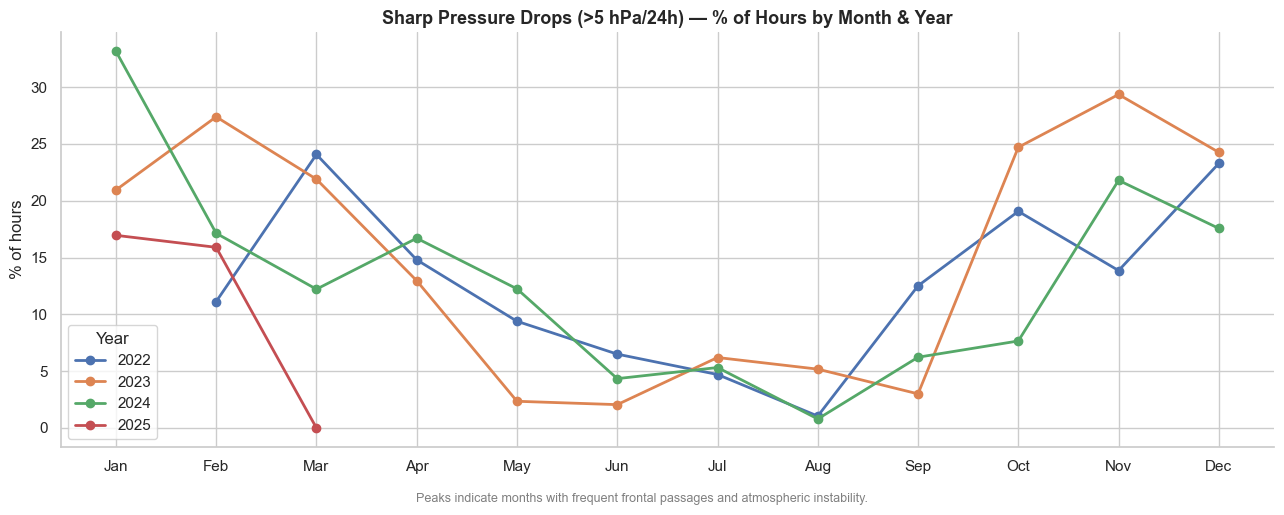

In [52]:
# B7 — Sharp pressure drops by month and year
drop_monthly = (
    weather.groupby(['year', 'month'], observed=True)['sharp_pressure_drop']
    .mean().mul(100).reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
for year, grp in drop_monthly.groupby('year'):
    ax.plot(grp['month'], grp['sharp_pressure_drop'],
            marker='o', linewidth=2, label=str(year))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Sharp Pressure Drops (>5 hPa/24h) — % of Hours by Month & Year',
             fontweight='bold', fontsize=13)
ax.set_ylabel('% of hours')
ax.legend(title='Year')
ax.spines[['top', 'right']].set_visible(False)
fig.text(0.5, -0.02,
    'Peaks indicate months with frequent frontal passages and atmospheric instability.',
    ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

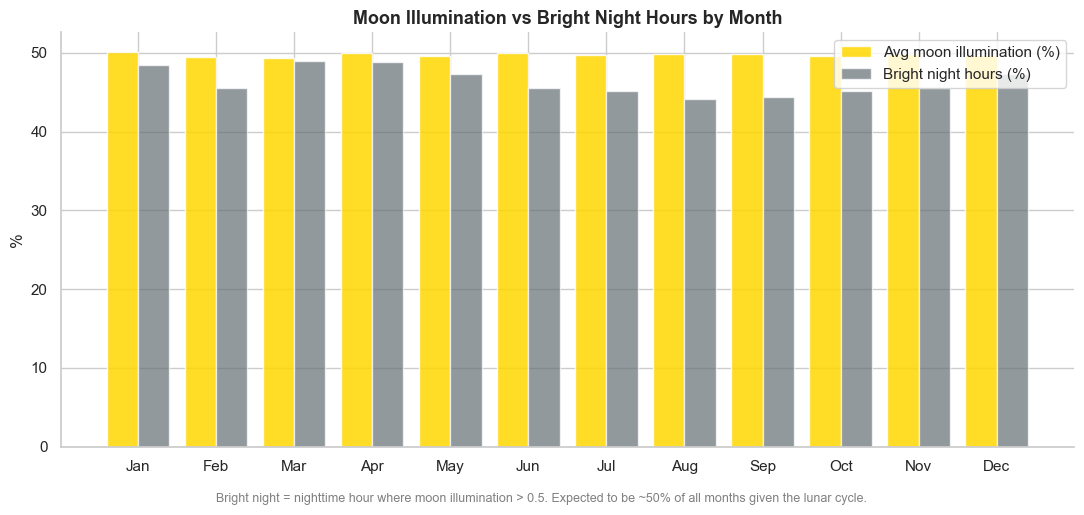

In [53]:
# B8 — Moon illumination vs bright night % by month
moon_monthly = (
    weather.groupby('month', observed=True)
    .agg(
        avg_illumination = ('moon_illumination', 'mean'),
        bright_night_pct = ('is_bright_night',   'mean')
    )
    .mul({'avg_illumination': 100, 'bright_night_pct': 100})
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(moon_monthly['month'] - 0.2, moon_monthly['avg_illumination'],
       width=0.4, color='gold', alpha=0.85, label='Avg moon illumination (%)')
ax.bar(moon_monthly['month'] + 0.2, moon_monthly['bright_night_pct'],
       width=0.4, color='#636e72', alpha=0.7, label='Bright night hours (%)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Moon Illumination vs Bright Night Hours by Month',
             fontweight='bold', fontsize=13)
ax.set_ylabel('%')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.text(0.5, -0.02,
    'Bright night = nighttime hour where moon illumination > 0.5. '
    'Expected to be ~50% of all months given the lunar cycle.',
    ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

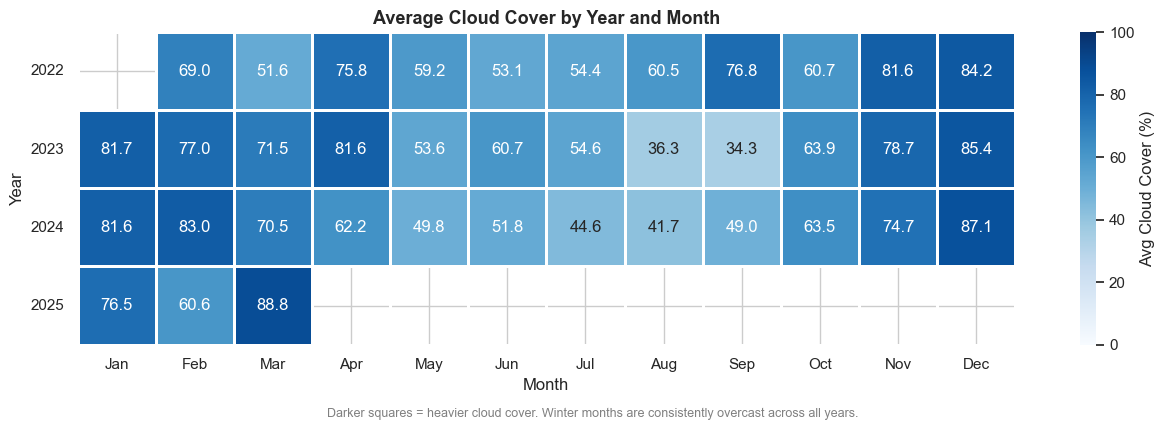

In [54]:
#B9 - Cloud cover distribution 
cloud_pivot = weather.pivot_table(
    index='year',
    columns='month',
    values='cloudcover',
    aggfunc='mean'
)
cloud_pivot.columns = month_names

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    cloud_pivot,
    cmap='Blues',
    annot=True,
    fmt='.1f',
    linewidths=2.0,
    linecolor='white',
    square=True,
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': 'Avg Cloud Cover (%)'}
)
ax.set_title('Average Cloud Cover by Year and Month',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.tick_params(axis='y', rotation=0)
fig.text(0.5, -0.04,
    'Darker squares = heavier cloud cover. '
    'Winter months are consistently overcast across all years.',
    ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

---

## 8. Summary of Findings

**Key findings for air alarm prediction:**

- **Temperature** — strong seasonality with consistent diurnal cycle across all cities.
  Eastern cities (Kharkiv, Zaporizhzhia) show the widest `temp_change_24h` ranges —
  higher day-to-day volatility signals frontal activity and atmospheric instability.

- **Pressure** — `sharp_pressure_drop` peaks October–February and is the fastest
  signal of an approaching front. `pressure_change_3h` captures short-term instability
  before it becomes visible in other variables.

- **Wind** — winter brings stronger northerly and north-easterly winds.
  `gust_ratio` is independent of all other features and captures turbulence uniquely.
  Sin/cos encoding of `winddir` preserves true geographic direction for the model.

- **Visibility** — fog peaks in October–December, overcast conditions persist
  October–March, reaching up to 70–85% cloud cover in winter. Low visibility
  limits aerial detection and correlates with conditions favourable for air raids.

- **Precipitation** — absent in 85%+ of hours and largely independent of other
  variables, meaning it carries unique signal. Western cities are consistently
  wetter — a geographic pattern the model should capture via city encoding.

- **Moon** — `is_bright_night` is uniformly distributed (~50% of nights year-round),
  introducing no seasonal bias. Full moon conditions increase nighttime ambient light,
  which is directly relevant to air defence detection capability.

- **Conditions** — binary flags (`is_fog`, `is_snow`, `is_overcast`, `is_rain`)
  show clear seasonal patterns and together describe the full visibility regime
  for each hour — a compact, model-ready representation of atmospheric state.

---

## 9. Feature Matrix — Final Preparation

### Columns Dropped Before Modeling

The following columns are removed from `weather` to produce the final
`weather_features` matrix. Each drop is justified by redundancy, prior encoding,
or lack of predictive signal:

| Column | Reason |
|---|---|
| `day_sunrise`, `day_sunset` | Used only to derive other features — raw strings not needed |
| `date` | Redundant — `datetime` is sufficient for indexing |
| `hours` | Duplicates `hour` |
| `day` | Low signal — `datetime` covers this |
| `season` | Replaced by binary flags `is_winter/spring/summer/autumn` |
| `moon_illumination` | Replaced by `is_bright_night` |
| `conditions`, `day_conditions`, `icon` | Parsed into binary flags in section 7.6 |
| `day_visibility` | Merged into `visibility` in section 4.2 |
| `region` | `city` column is sufficient for merging |
| `day_moonphase` | Encoded into `moon_illumination` → `is_bright_night` |
| `year`, `month`, `weekday`, `hour` | Temporal context encoded via cyclical and binary features |
|`is_windy_category`| Quasi-constant value |
|`temp`| Еemp and rolling_temp_24h measure the same underlying signal — the rolling mean is computed directly from temp over a 24-hour window, so they are nearly identical |


In [55]:
drop_cols = [
    'day_sunrise',   
    'day_sunset',   
    'date',         
    'hours',           
    'day',              
    'moon_illumination',
    'conditions',     
    'day_conditions',   
    'icon',            
    'day_visibility',   
    'region',    
    'season',
    'day_moonphase',
    'year',
    'month',
    'weekday',
    'hour',
    'is_windy_category',
    'temp'
]

# Drop only columns that actually exist (guards against re-runs)
drop_cols_existing = [c for c in drop_cols if c in weather.columns]

weather_features = weather.drop(columns=drop_cols_existing)

In [56]:
# Final dataset results
print(f'Shape:      {weather_features.shape}')
print(f'Memory:     {weather_features.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'Any NaN:    {weather_features.isna().sum().sum()}')
print(f'Duplicates: {weather_features.duplicated().sum()}')
print(f'Date range: {weather_features["datetime"].min()} → {weather_features["datetime"].max()}')
print(f'\nDtypes:\n{weather_features.dtypes.to_string()}')

Shape:      (608235, 41)
Memory:     190.9 MB
Any NaN:    0
Duplicates: 0
Date range: 2022-02-24 00:00:00 → 2025-03-01 23:00:00

Dtypes:
city                           object
datetime               datetime64[ns]
humidity                      float64
dew                           float64
pressure                      float64
precip                        float64
precipprob                    float64
cloudcover                    float64
snow                          float64
windspeed                     float64
winddir                       float64
windgust                      float64
visibility                    float64
is_winter                        int8
is_spring                        int8
is_summer                        int8
is_autumn                        int8
rolling_temp_24h              float64
temp_change_24h               float64
rolling_precip_24h            float64
precip_sum_6h                 float64
is_rainy_hour                    int8
is_heavy_rain              


### City Name Standardization

Before saving, city names are normalized from API format to standard Ukrainian
transliteration using a lookup dictionary. Two names are corrected from
Russian-based spellings: `Zaporozhye` → `Zaporizhzhia` and
`Uzhgorod` → `Uzhhorod`. The `city` column is cast to `category` dtype
for memory efficiency.

In [57]:
# Unique cities check
print('Cities in weather_model:')
print(sorted(weather_features['city'].unique().tolist()))

Cities in weather_model:
['Cherkasy', 'Chernihiv', 'Chernivtsi', 'Dnipro', 'Donetsk', 'Ivano-Frankivsk', 'Kharkiv', 'Kherson', 'Khmelnytskyi', 'Kropyvnytskyi', 'Kyiv', 'Lutsk', 'Lviv', 'Mykolaiv', 'Odesa', 'Poltava', 'Rivne', 'Sumy', 'Ternopil', 'Uzhgorod', 'Vinnytsia', 'Zaporozhye', 'Zhytomyr']


In [58]:
city_translit = {
    'Cherkasy':        'Cherkasy',
    'Chernihiv':       'Chernihiv',
    'Chernivtsi':      'Chernivtsi',
    'Dnipro':          'Dnipro',
    'Donetsk':         'Donetsk',
    'Ivano-Frankivsk': 'Ivano-Frankivsk',
    'Kharkiv':         'Kharkiv',
    'Kherson':         'Kherson',
    'Khmelnytskyi':    'Khmelnytskyi',
    'Kropyvnytskyi':   'Kropyvnytskyi',
    'Kyiv':            'Kyiv',
    'Lutsk':           'Lutsk',
    'Lviv':            'Lviv',
    'Mykolaiv':        'Mykolaiv',
    'Odesa':           'Odesa',
    'Poltava':         'Poltava',
    'Rivne':           'Rivne',
    'Sumy':            'Sumy',
    'Ternopil':        'Ternopil',
    'Uzhgorod':        'Uzhhorod',
    'Vinnytsia':       'Vinnytsia',
    'Zaporozhye':      'Zaporizhzhia',
    'Zhytomyr':        'Zhytomyr',
    'Zaporizhzhia':    'Zaporizhzhia',
    'Uzhhorod':        'Uzhhorod',
}

weather_features['city'] = weather_features['city'].map(
    lambda x: city_translit.get(x, x)
).astype('category')

print('Cities after normalization:')
print(sorted(weather_features['city'].unique().tolist()))

Cities after normalization:
['Cherkasy', 'Chernihiv', 'Chernivtsi', 'Dnipro', 'Donetsk', 'Ivano-Frankivsk', 'Kharkiv', 'Kherson', 'Khmelnytskyi', 'Kropyvnytskyi', 'Kyiv', 'Lutsk', 'Lviv', 'Mykolaiv', 'Odesa', 'Poltava', 'Rivne', 'Sumy', 'Ternopil', 'Uzhhorod', 'Vinnytsia', 'Zaporizhzhia', 'Zhytomyr']


In [59]:
# Final save
weather_features.to_csv('weather_features_hourly.csv', index=False)
print(f'Saved → weather_features_hourly.csv | shape: {weather_features.shape}')
print('Ready for merge with alarms, ISW, Telegram, and Reddit datasets.')

Saved → weather_features_hourly.csv | shape: (608235, 41)
Ready for merge with alarms, ISW, Telegram, and Reddit datasets.
